# Parte 2 — Series Temporales, Feature Engineering y Modelado

## Definición del problema de forecasting

El objetivo del Grupo 7 es desarrollar un modelo capaz de pronosticar la
potencia activa global promedio del hogar para la próxima hora.

- **Variable objetivo:** `Global_active_power`
- **Frecuencia original:** 1 minuto
- **Frecuencia de modelado:** 1 hora
- **Agregación del target:** promedio horario
- **Horizonte de predicción:** t + 1 hora
- **Métricas principales:** MAE y RMSE

Para cada hora que se desea pronosticar, el modelo utilizará únicamente
información disponible en horas anteriores, evitando el uso de información
contemporánea o futura que pueda producir data leakage.

# 1. Importar librerías

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 2. Ejecutar la Ingesta

In [3]:
%run src/ingestion/ingest.py

El archivo ZIP ya existe.
El dataset ya fue extraído.
Ingesta completada
Dataset disponible en: C:\Git\Household-power-g7\Proyecto-Household-Power-G7\data\raw\household_power_consumption.txt


# 3. Definir el Archivo

In [4]:
ROOT_DIR = Path.cwd()

RAW_FILE = (
    ROOT_DIR
    / "data"
    / "raw"
    / "household_power_consumption.txt"
)

if not RAW_FILE.exists():
    raise FileNotFoundError(
        "No se encontró el archivo de datos después de ejecutar la ingesta."
    )

print("Dataset:", RAW_FILE)

Dataset: c:\Git\Household-power-g7\Proyecto-Household-Power-G7\data\raw\household_power_consumption.txt


# 4. Cargar el RAW

In [5]:
columnas = [
    "Date",
    "Time",
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

df = pd.read_csv(
    RAW_FILE,
    sep=";",
    na_values=["?"],
    usecols=columnas,
    low_memory=False,
)

print("Dimensiones:", df.shape)

display(df.head())

Dimensiones: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


# 5. Preparación de la Serie Temporal

## 5.1 Construcción del índice temporal

In [6]:
df["datetime"] = pd.to_datetime(
    df["Date"].astype(str)
    + " "
    + df["Time"].astype(str),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)

df = (
    df
    .drop(columns=["Date", "Time"])
    .set_index("datetime")
    .sort_index()
)

display(df.head())

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Comprobamos que el índice temporal quedó bien:

In [7]:
print(
    "Índice ordenado:",
    df.index.is_monotonic_increasing
)

print(
    "Timestamps duplicados:",
    df.index.duplicated().sum()
)

print(
    "Fecha inicial:",
    df.index.min()
)

print(
    "Fecha final:",
    df.index.max()
)

Índice ordenado: True
Timestamps duplicados: 0
Fecha inicial: 2006-12-16 17:24:00
Fecha final: 2010-11-26 21:02:00


Lo que indica el código anterior no sustituye el análisis del Notebook 01; simplemente se comprueba que la transformación no rompió nada.

**Resultado:** La conversión de `Date` y `Time` a un índice `datetime` fue
exitosa. El índice se encuentra ordenado cronológicamente, no presenta
timestamps duplicados y conserva el mismo período temporal identificado
durante el diagnóstico del Notebook 01.

## 5.2 Resampling y creación de la serie horaria

### Criterio de agregación horaria

El dataset original contiene observaciones con frecuencia de un minuto. Para
el modelado se decidió trabajar a frecuencia horaria con el objetivo de
reducir el volumen de datos sin perder los patrones intradiarios identificados
durante el EDA.

Las variables eléctricas no poseen todas la misma unidad, por lo que la
agregación horaria se realiza de acuerdo con su significado físico:

- `Global_active_power`: promedio horario.
- `Global_reactive_power`: promedio horario.
- `Voltage`: promedio horario.
- `Global_intensity`: promedio horario.
- `Sub_metering_1`: suma horaria.
- `Sub_metering_2`: suma horaria.
- `Sub_metering_3`: suma horaria.

El promedio se utiliza para las variables que representan magnitudes medidas
durante el minuto, mientras que los submedidores se agregan mediante suma
porque representan energía en Wh registrada durante cada intervalo.

In [8]:
df_hourly = pd.DataFrame({
    "Global_active_power":
        df["Global_active_power"].resample("h").mean(),

    "Global_reactive_power":
        df["Global_reactive_power"].resample("h").mean(),

    "Voltage":
        df["Voltage"].resample("h").mean(),

    "Global_intensity":
        df["Global_intensity"].resample("h").mean(),

    "Sub_metering_1":
        df["Sub_metering_1"].resample("h").sum(min_count=1),

    "Sub_metering_2":
        df["Sub_metering_2"].resample("h").sum(min_count=1),

    "Sub_metering_3":
        df["Sub_metering_3"].resample("h").sum(min_count=1),
})

In [9]:
# Contar cuántos minutos válidos tiene cada hora
df_hourly["valid_minutes"] = (
    df["Global_active_power"]
    .resample("h")
    .count()
)

df_hourly["coverage_pct"] = (
    df_hourly["valid_minutes"] / 60 * 100
)

display(df_hourly.head())

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,valid_minutes,coverage_pct
datetime,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,19.0,607.0,36,60.0
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,403.0,1012.0,60,100.0
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,86.0,1001.0,60,100.0
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.0,1007.0,60,100.0
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,25.0,1033.0,60,100.0


## 5.3 Evaluación de la cobertura horaria

In [10]:
# Estudiar la cobertura horaria
distribucion_cobertura = (
    df_hourly["valid_minutes"]
    .value_counts()
    .sort_index()
)

display(distribucion_cobertura)

valid_minutes
0       421
2         2
3         1
9         2
21        2
25        1
28        2
29        1
30        1
32        1
36        3
39        1
47        1
48        1
49        2
52        2
53        2
54        1
56        3
57        1
58       15
59       38
60    34085
Name: count, dtype: int64

In [11]:
print(
    "Horas totales:",
    len(df_hourly)
)

print(
    "Horas completas:",
    (df_hourly["valid_minutes"] == 60).sum()
)

print(
    "Horas sin ninguna medición:",
    (df_hourly["valid_minutes"] == 0).sum()
)

print(
    "Horas parcialmente observadas:",
    (
        (df_hourly["valid_minutes"] > 0)
        & (df_hourly["valid_minutes"] < 60)
    ).sum()
)

Horas totales: 34589
Horas completas: 34085
Horas sin ninguna medición: 421
Horas parcialmente observadas: 83


### Hallazgos de cobertura horaria

Después del resampling se obtuvieron 34,589 intervalos horarios.

- **34,085 horas (≈98.54%)** contienen las 60 observaciones esperadas.
- **421 horas** no contienen ninguna medición eléctrica válida.
- **83 horas** poseen cobertura parcial, es decir, contienen entre 1 y 59
  observaciones válidas.

Estos resultados muestran que la gran mayoría de la serie presenta cobertura
completa. Los problemas de datos faltantes se concentran en un número reducido
de intervalos horarios.

In [12]:
# Eliminación de horas incompletas por los límites del dataset
df_hourly = df_hourly.iloc[1:-1].copy()

### Tratamiento de las horas límite

La primera y la última observación horaria se excluyen del análisis debido a
que no representan horas completas por diseño del dataset.

La primera observación comienza a las 17:24 del 16/12/2006 y la última termina
a las 21:02 del 26/11/2010. Su cobertura parcial no corresponde a un problema
de calidad o pérdida de datos, sino a los límites naturales del período de
recolección.

Por esta razón, ambas observaciones se eliminan antes de evaluar la cobertura
de las horas internas de la serie.

## 5.4 Definición de horas válidas

Para que el promedio horario represente adecuadamente el comportamiento
eléctrico durante la hora, se establece un criterio mínimo de cobertura.

Cada intervalo horario debería contener 60 observaciones, correspondientes a
las mediciones minuto a minuto del dataset original.

Se considera una **hora válida** aquella que contiene al menos el **90% de las
mediciones esperadas**, equivalente a:

$$
60 \times 0.90 = 54
$$

Por tanto:

- **54–60 minutos válidos:** la hora se considera suficientemente
  representada.
- **0–53 minutos válidos:** la hora se considera de cobertura insuficiente.

La elección del 90% se basa en el análisis de cobertura realizado previamente.
La gran mayoría de las horas posee 60 observaciones y, entre las horas
parcialmente observadas, muchas contienen 58 o 59 registros. El criterio
permite conservar horas casi completas evitando representar un intervalo
horario mediante un número reducido de mediciones.

**Nota sobre los submedidores:** En las horas con cobertura parcial aceptada
(54–59 minutos), las sumas de `Sub_metering_1`, `Sub_metering_2` y
`Sub_metering_3` corresponden únicamente a los minutos observados y podrían
subestimar ligeramente la energía horaria real. Estas variables no se
utilizarán automáticamente como predictores sin evaluar previamente este
efecto durante el Feature Engineering.

In [13]:
MIN_VALID_MINUTES = 54

horas_baja_cobertura = (
    df_hourly["valid_minutes"] < MIN_VALID_MINUTES
)

print(
    "Horas con cobertura insuficiente:",
    horas_baja_cobertura.sum()
)

print(
    "Porcentaje de horas con cobertura insuficiente:",
    round(
        horas_baja_cobertura.mean() * 100,
        2
    ),
    "%"
)

Horas con cobertura insuficiente: 444
Porcentaje de horas con cobertura insuficiente: 1.28 %


### Tratamiento de las horas con cobertura insuficiente

Las horas clasificadas con cobertura insuficiente no se eliminan del índice
temporal. En su lugar, sus variables eléctricas se marcan como valores
faltantes (`NaN`).

Esta decisión permite conservar la continuidad de la serie horaria. Mantener
todos los timestamps será especialmente importante durante la creación de
variables rezagadas (`lags`), ya que eliminar una hora podría provocar que dos
observaciones separadas por más de una hora fueran interpretadas
incorrectamente como observaciones consecutivas.

In [14]:
columnas_electricas = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

df_hourly.loc[
    horas_baja_cobertura,
    columnas_electricas
] = np.nan

In [15]:
missing_hourly = pd.DataFrame({
    "Missing": df_hourly.isna().sum(),
    "Porcentaje": (
        df_hourly.isna().mean() * 100
    ).round(2),
})

display(missing_hourly)

,Missing,Porcentaje
Global_active_power,444,1.28
Global_reactive_power,444,1.28
Voltage,444,1.28
Global_intensity,444,1.28
Sub_metering_1,444,1.28
Sub_metering_2,444,1.28
Sub_metering_3,444,1.28
valid_minutes,0,0.00
coverage_pct,0,0.00


## 5.5 Calidad de datos posterior al resampling 

Después de transformar las observaciones minuto a minuto a frecuencia horaria
y aplicar el criterio mínimo de cobertura del 90%, se realiza una nueva
evaluación de calidad sobre la serie resultante.

El objetivo de esta validación no es repetir el diagnóstico realizado en el
Notebook 01, sino comprobar que el proceso de preparación temporal produjo una
serie consistente y adecuada para las siguientes etapas del análisis.

### Valores faltantes posteriores al resampling

Después de aplicar el criterio de cobertura:

- Se conservan **34,587 intervalos horarios internos**.
- **444 horas (1.28%)** presentan cobertura insuficiente y sus mediciones
  eléctricas fueron representadas como `NaN`.
- **34,143 horas (98.72%)** cumplen el criterio mínimo de cobertura.
- Las variables `valid_minutes` y `coverage_pct` permanecen completas porque
  representan información sobre la calidad de cada intervalo horario y no
  mediciones eléctricas.

Los valores faltantes no serán eliminados ni imputados en esta etapa. Se
mantendrá la estructura horaria completa para evitar alterar la distancia
temporal entre observaciones.

El tratamiento definitivo de estos registros dependerá de las necesidades de
cada análisis y del Feature Engineering posterior.

In [16]:
print(
    "Índice horario ordenado:",
    df_hourly.index.is_monotonic_increasing
)

print(
    "Timestamps horarios duplicados:",
    df_hourly.index.duplicated().sum()
)

diferencias_horarias = (
    df_hourly.index
    .to_series()
    .diff()
    .dropna()
)

print(
    "Intervalos diferentes de 1 hora:",
    (diferencias_horarias != pd.Timedelta(hours=1)).sum()
)

print(
    "Missing en target:",
    df_hourly["Global_active_power"].isna().sum()
)

print(
    "Porcentaje missing en target:",
    round(
        df_hourly["Global_active_power"].isna().mean() * 100,
        2
    ),
    "%"
)

Índice horario ordenado: True
Timestamps horarios duplicados: 0
Intervalos diferentes de 1 hora: 0
Missing en target: 444
Porcentaje missing en target: 1.28 %


### Resultado de la preparación temporal

La transformación produjo una serie temporal horaria regular, ordenada y sin
timestamps duplicados.

Los intervalos mantienen una separación constante de una hora, incluyendo
aquellos períodos en los que las mediciones eléctricas fueron clasificadas
como faltantes por cobertura insuficiente.

El **98.72% de las horas** cumple el criterio mínimo de cobertura establecido,
mientras que el **1.28% restante** se conserva dentro del índice temporal con
valores `NaN`.

Por tanto, la serie queda preparada para continuar con el análisis de su
comportamiento temporal antes de construir las variables predictoras.

# 6. Análisis de la Serie Temporal

## 6.1 Serie horaria completa

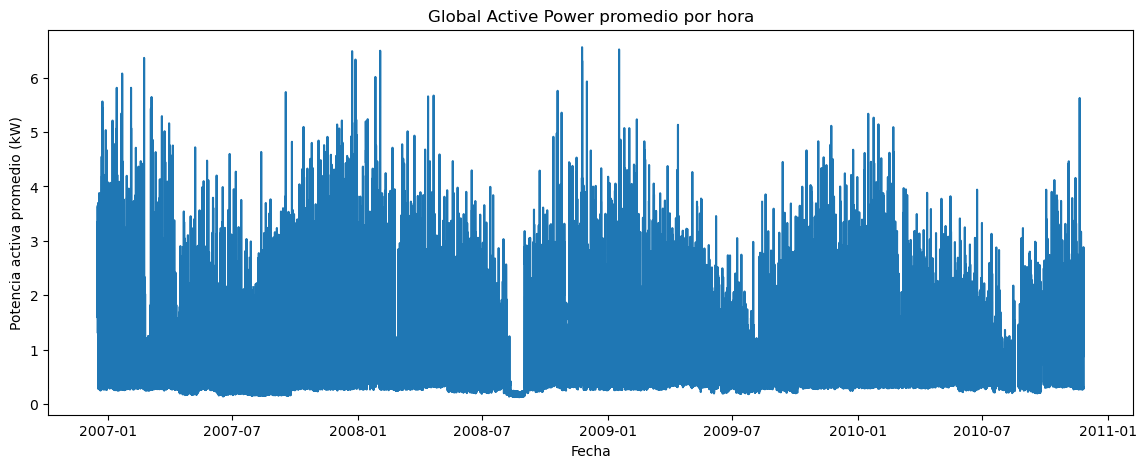

In [17]:
plt.figure(figsize=(14, 5))

plt.plot(
    df_hourly.index,
    df_hourly["Global_active_power"]
)

plt.title(
    "Global Active Power promedio por hora"
)
plt.xlabel("Fecha")
plt.ylabel("Potencia activa promedio (kW)")
plt.show()


**Hallazgos:** La serie horaria de Global_active_power presenta una elevada variabilidad de corto plazo, con períodos de consumo relativamente bajo y episodios de mayor demanda que alcanzan valores superiores a 4, 5 y 6 kW. Además, se observan cambios recurrentes en el nivel general de consumo a lo largo del período analizado. Visualmente, los niveles tienden a ser mayores en determinados períodos del año y menores en otros, lo que sugiere la presencia de una estructura temporal de mediano y largo plazo. Por esta razón, la serie no debe tratarse como si todas las horas tuvieran el mismo comportamiento esperado independientemente del momento del año.

## 6.2 Análisis de una semana

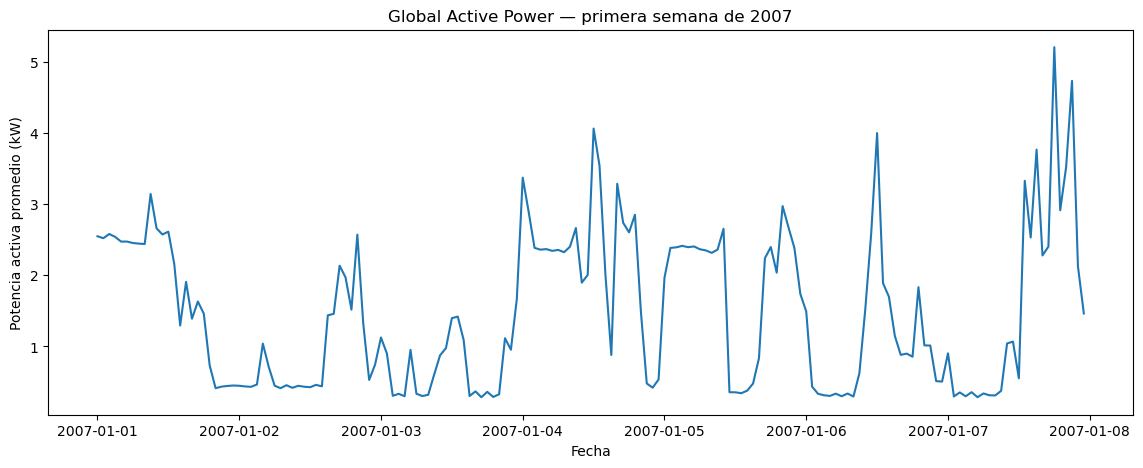

In [18]:
muestra_semana = df_hourly.loc[
    "2007-01-01":"2007-01-07"
]

plt.figure(figsize=(14, 5))

plt.plot(
    muestra_semana.index,
    muestra_semana["Global_active_power"]
)

plt.title(
    "Global Active Power — primera semana de 2007"
)
plt.xlabel("Fecha")
plt.ylabel("Potencia activa promedio (kW)")
plt.show()

**Hallazgos:** Al observar una semana a frecuencia horaria se aprecia una estructura intradiaria clara. El consumo alterna entre períodos de menor demanda y períodos con incrementos y picos, y estos comportamientos vuelven a presentarse a lo largo de los distintos días. Esto demuestra que las observaciones no son temporalmente independientes y respalda la decisión de trabajar a frecuencia horaria en lugar de diaria, ya que una agregación diaria eliminaría buena parte de esta información intradiaria.

## 6.3 Tendencia / Medias móviles

In [19]:
serie = df_hourly["Global_active_power"]

media_24h = serie.rolling(24).mean()

media_7d = serie.rolling(24 * 7).mean()

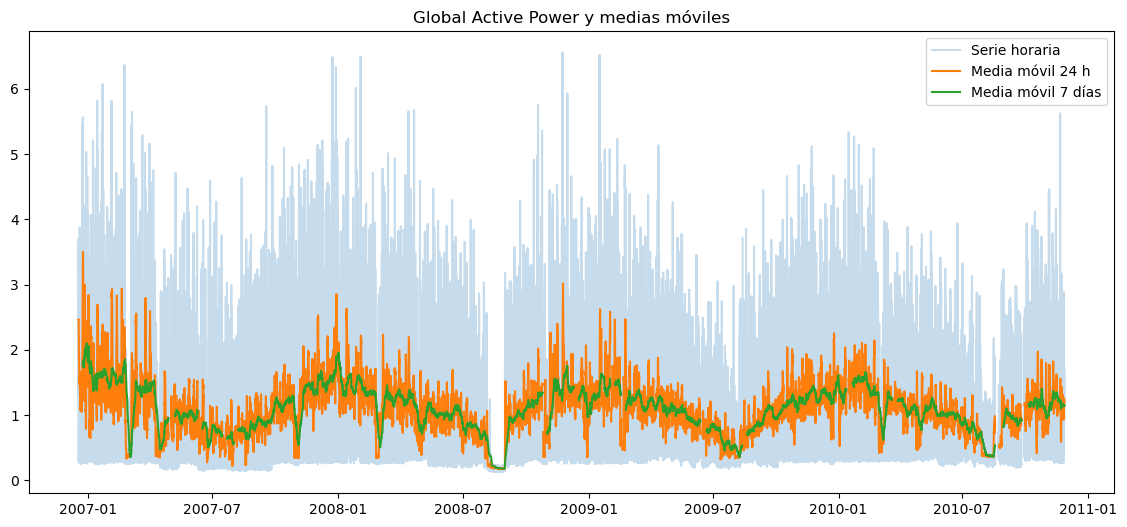

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(
    serie.index,
    serie,
    alpha=0.25,
    label="Serie horaria"
)

plt.plot(
    media_24h.index,
    media_24h,
    label="Media móvil 24 h"
)

plt.plot(
    media_7d.index,
    media_7d,
    label="Media móvil 7 días"
)

plt.title(
    "Global Active Power y medias móviles"
)
plt.legend()
plt.show()

**Hallazgos:** La serie horaria presenta una fuerte variabilidad de corto plazo. La media móvil de 24 horas permite suavizar parte de esta variabilidad diaria, mientras que la media móvil de 7 días (168 horas) permite observar con mayor claridad la evolución del nivel promedio de consumo. No se identifica una tendencia monotónica sostenida de crecimiento o disminución durante todo el período. Sin embargo, sí se observa una estructura recurrente de mediano y largo plazo, con períodos de mayor y menor consumo que reaparecen a lo largo de los años. Esto sugiere la existencia de componentes estacionales además de la dinámica horaria.


## 6.4 Preparación de serie para diagnóstico


In [21]:
# Serie horaria original
serie = df_hourly["Global_active_power"]

# Identificar qué observaciones tienen un valor válido
es_valido = serie.notna()

# Crear identificadores para cada bloque continuo
bloque_id = (
    es_valido
    .ne(es_valido.shift())
    .cumsum()
)

# Calcular el tamaño de cada bloque continuo con datos válidos
tamano_bloques = (
    serie[es_valido]
    .groupby(bloque_id[es_valido])
    .size()
)

# Identificar el bloque continuo más largo
bloque_mas_largo = tamano_bloques.idxmax()

# Extraer únicamente ese bloque
serie_diagnostico = serie[
    es_valido
    & (bloque_id == bloque_mas_largo)
]

print("Inicio:", serie_diagnostico.index.min())
print("Fin:", serie_diagnostico.index.max())
print("Observaciones:", len(serie_diagnostico))

Inicio: 2007-08-01 09:00:00
Fin: 2008-10-25 09:00:00
Observaciones: 10825


In [22]:
# Verificación de Continuidad 
diferencias_tiempo = (
    serie_diagnostico
    .index
    .to_series()
    .diff()
    .dropna()
)

continuidad_horaria = (
    diferencias_tiempo
    == pd.Timedelta(hours=1)
).all()

print(
    "¿Todas las observaciones son consecutivas cada hora?",
    continuidad_horaria
)

¿Todas las observaciones son consecutivas cada hora? True


**Preparación para diagnóstico:** Para evitar que la eliminación directa de valores faltantes alterara la interpretación temporal de los lags, se identificó el bloque continuo más largo de observaciones horarias válidas. El bloque seleccionado contiene 10.825 observaciones consecutivas, desde el 1 de agosto de 2007 a las 09:00 hasta el 25 de octubre de 2008 a las 09:00. Se verificó además que todas las observaciones están separadas exactamente por una hora. Este bloque se utiliza exclusivamente para los diagnósticos ACF, PACF y ADF, garantizando que, por ejemplo, un lag de 24 represente efectivamente 24 horas.

## 6.5 ACF

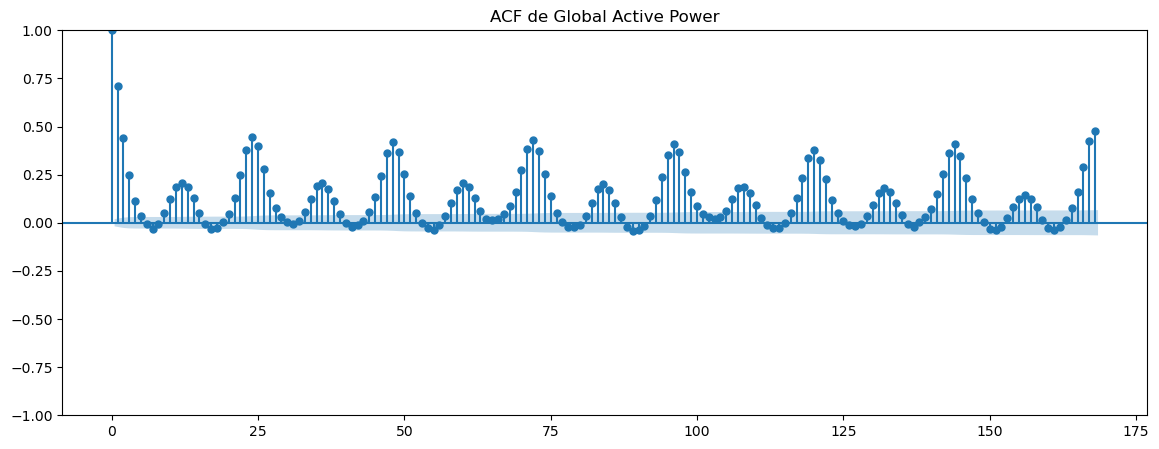

In [23]:
fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    serie_diagnostico,
    lags=168,
    ax=ax
)

plt.title(
    "ACF de Global Active Power"
)
plt.show()

**Hallazgos:** La función de autocorrelación muestra una dependencia temporal importante entre observaciones consecutivas. El lag 1 presenta una autocorrelación cercana a 0.71, indicando que el nivel observado en la hora anterior contiene información relevante sobre el consumo de la hora actual. La autocorrelación disminuye conforme aumenta la distancia temporal inmediata, pero vuelve a incrementarse aproximadamente cada 24 horas. Este patrón periódico constituye evidencia de una estructura estacional diaria. Además, el comportamiento se mantiene en múltiplos de 24 horas hasta alcanzar 168 horas, correspondientes a una semana.


## 6.6 Autocorrelaciones de lags relevantes

In [24]:
lags_interes = [
    1,
    2,
    24,
    48,
    72,
    168,
]

autocorrelaciones = pd.DataFrame({
    "Lag_horas": lags_interes,
    "Interpretacion": [
        "Hora anterior",
        "Dos horas anteriores",
        "Misma hora del día anterior",
        "Misma hora de hace dos días",
        "Misma hora de hace tres días",
        "Misma hora de la semana anterior",
    ],
    "Autocorrelacion": [
        serie_diagnostico.autocorr(lag=lag)
        for lag in lags_interes
    ],
})

display(autocorrelaciones)

,Lag_horas,Interpretacion,Autocorrelacion
0,1,Hora anterior,0.709967
1,2,Dos horas anteriores,0.442376
2,24,Misma hora del día anterior,0.447157
3,48,Misma hora de hace dos días,0.421594
4,72,Misma hora de hace tres días,0.434201
5,168,Misma hora de la semana anterior,0.487195


Los lags seleccionados confirman cuantitativamente los patrones observados en la ACF. La mayor autocorrelación corresponde al lag 1 (0.710), lo que evidencia una fuerte persistencia de corto plazo. El lag 24 presenta una autocorrelación de 0.447, respaldando la existencia de una periodicidad diaria. El lag 168 alcanza aproximadamente 0.487, lo que aporta evidencia adicional de una estructura semanal. Estos resultados justifican evaluar lag_1, lag_24 y lag_168 como características predictoras durante el Feature Engineering.

## 6.7 PACF

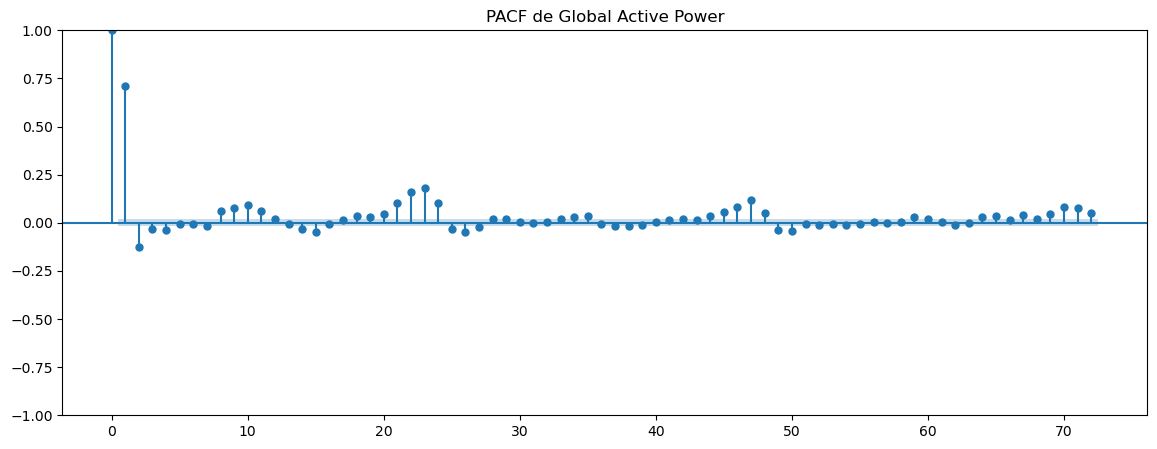

In [25]:
fig, ax = plt.subplots(figsize=(14, 5))

plot_pacf(
    serie_diagnostico,
    lags=72,
    method="ywm",
    ax=ax
)

plt.title(
    "PACF de Global Active Power"
)
plt.show()

**Hallazgos:** La PACF confirma que el lag 1 posee la relación directa más fuerte con el consumo actual. Una vez controlado el efecto de los lags intermedios, las asociaciones restantes son considerablemente menores. Sin embargo, persisten estructuras alrededor de 24, 48 y 72 horas, lo cual es coherente con el patrón diario identificado mediante la ACF. La combinación de ACF y PACF refuerza la importancia de la dependencia inmediatamente anterior y de los componentes estacionales diarios.

## 6.8 Estacionariedad - ADF

In [26]:
resultado_adf = adfuller(
    serie_diagnostico,
    autolag="AIC"
)

print(
    "ADF Statistic:",
    resultado_adf[0]
)

print(
    "p-value:",
    resultado_adf[1]
)

print(
    "Critical Values:"
)

for clave, valor in resultado_adf[4].items():
    print(
        f"  {clave}: {valor}"
    )

ADF Statistic: -9.210139197480393
p-value: 1.8974838789769783e-15
Critical Values:
  1%: -3.4309563647738046
  5%: -2.861807979313397
  10%: -2.5669126402527156


**Hallazgos:** La prueba Augmented Dickey-Fuller aplicada al bloque horario continuo utilizado para diagnóstico produjo un estadístico ADF de -9.210 y un p-value aproximado de \(1.90\times10^{-15}\). Este valor es considerablemente inferior al nivel de significancia de 0.05. Además, el estadístico ADF es más negativo que los valores críticos correspondientes al 1%, 5% y 10%. Por lo tanto, se rechaza la hipótesis nula de presencia de raíz unitaria en el bloque analizado. Este resultado indica que no existe evidencia de una tendencia estocástica que haga necesaria una primera diferenciación para los modelos inicialmente considerados.

## 6.9 Conclusiones

El análisis de la serie muestra que el consumo eléctrico cambia bastante entre horas y que existen patrones que se repiten con el tiempo.

La ACF mostró que el consumo de una hora está relacionado con horas anteriores. Los resultados más importantes fueron:

lag_1: 0.710
lag_24: 0.447
lag_168: 0.487

Esto indica que la hora anterior, la misma hora del día anterior y la misma hora de la semana anterior pueden aportar información útil para realizar el pronóstico.

La PACF también mostró que el lag_1 tiene una relación importante con el consumo actual y que existen patrones alrededor de las 24 horas.

Por último, la prueba ADF obtuvo un p-value mucho menor a 0.05, por lo que se rechaza la hipótesis de raíz unitaria. Por esta razón, inicialmente no se realizará diferenciación de la serie.

# 7. Feature Engineering

A partir de los resultados obtenidos durante el EDA y el análisis de la serie
temporal, se construirán variables predictoras capaces de representar tres
tipos de información:

1. **Información de calendario**, para representar los patrones asociados al
   momento en que ocurre cada observación.
2. **Información histórica**, mediante valores rezagados de
   `Global_active_power`.
3. **Información reciente agregada**, que podrá evaluarse posteriormente
   mediante ventanas móviles.

Las variables se construirán respetando estrictamente el orden temporal. Para
predecir la potencia activa global de una hora determinada, solo podrá
utilizarse información disponible antes de esa hora, evitando data leakage.

## 7.1 Copia para modelado

In [27]:
df_model = df_hourly.copy()

In [28]:
print(df_model.columns.tolist())

['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'valid_minutes', 'coverage_pct']


## 7.2 Variables de calendario / Información de calendario

In [29]:
df_model["hour"] = df_model.index.hour 

df_model["day_of_week"] = df_model.index.dayofweek # Significa 0(lunes), 1(martes), 2(miércoles), 3(jueves), 4(viernes), 5(sábado) y 6(domingo)

df_model["month"] = df_model.index.month

df_model["is_weekend"] = ( # Significa 0(lunes a viernes) y 1(sábado a domingo)
    df_model.index.dayofweek >= 5
).astype(int)

In [30]:
display(
    df_model[
        [
            "Global_active_power",
            "hour",
            "day_of_week",
            "month",
            "is_weekend",
        ]
    ].head(24)
)

,Global_active_power,hour,day_of_week,month,is_weekend
datetime,,,,,
2006-12-16 18:00:00,3.632200,18,5,12,1
2006-12-16 19:00:00,3.400233,19,5,12,1
2006-12-16 20:00:00,3.268567,20,5,12,1
2006-12-16 21:00:00,3.056467,21,5,12,1
2006-12-16 22:00:00,2.200133,22,5,12,1
2006-12-16 23:00:00,2.061600,23,5,12,1
2006-12-17 00:00:00,1.882467,0,6,12,1
2006-12-17 01:00:00,3.349400,1,6,12,1
2006-12-17 02:00:00,1.587267,2,6,12,1


### 7.2.1 Codificación cíclica de la hora y el mes

Las variables `hour` y `month` representan ciclos temporales. Por ejemplo, las 23:00 y las 00:00 son horas consecutivas, aunque numéricamente 23 y 0 parezcan muy alejadas. Lo mismo ocurre entre diciembre (12) y enero (1).

Para representar correctamente esta naturaleza cíclica, se transforman ambas variables mediante funciones seno y coseno. De esta forma, el modelo puede reconocer que el final y el inicio de cada ciclo están próximos entre sí y representar mejor los patrones diarios y anuales presentes en la serie temporal.

### Hora

In [31]:
df_model["hour_sin"] = np.sin(
    2 * np.pi * df_model["hour"] / 24
)

df_model["hour_cos"] = np.cos(
    2 * np.pi * df_model["hour"] / 24
)

### Mes

In [32]:
df_model["month_sin"] = np.sin(
    2 * np.pi * (df_model["month"] - 1) / 12
)

df_model["month_cos"] = np.cos(
    2 * np.pi * (df_model["month"] - 1) / 12
)

### Día de la Semana

In [33]:
df_model["day_of_week_sin"] = np.sin(
    2 * np.pi * df_model["day_of_week"] / 7
)

df_model["day_of_week_cos"] = np.cos(
    2 * np.pi * df_model["day_of_week"] / 7
)

Al igual que la hora y el mes, el día de la semana presenta un comportamiento cíclico: después del domingo vuelve el lunes. Por esta razón se genera también una representación mediante seno y coseno.

## 7.3 Lag Features / Información histórica

### lag_1

Significa potencia activa de una hora antes.
Ejemplo: si se quiere predecir la hora 15:00, entonces el lag_1 es igual a Global_active_power de 14:00.

In [34]:
df_model["lag_1"] = (
    df_model["Global_active_power"]
    .shift(1)
)

### lag_24

Ejemplo: para predecir el martes a las 15:00, se tendrá aproximadamente el lunes 15:00. Es decir, la misma hora del día anterior.

In [35]:
df_model["lag_24"] = (
    df_model["Global_active_power"]
    .shift(24)
)

### lag_168
Una semana antes de predicción.


In [36]:
df_model["lag_168"] = (
    df_model["Global_active_power"]
    .shift(168)
)

### Comprobación del funcionamiento de los lags

In [37]:
display(
    df_model[
        [
            "Global_active_power",
            "lag_1",
            "lag_24",
            "lag_168",
        ]
    ].loc["2007-01-08 00:00":"2007-01-08 05:00"]
)

,Global_active_power,lag_1,lag_24,lag_168
datetime,,,,
2007-01-08 00:00:00,1.360467,1.463867,0.903200,2.550633
2007-01-08 01:00:00,1.350667,1.360467,0.296433,2.523400
2007-01-08 02:00:00,1.384833,1.350667,0.352400,2.582333
2007-01-08 03:00:00,1.356900,1.384833,0.298667,2.541667
2007-01-08 04:00:00,1.375900,1.356900,0.355867,2.475733
2007-01-08 05:00:00,1.104533,1.375900,0.285367,2.476233


### Prevención de data leakage

Las variables rezagadas se construyen mediante `shift()`, asegurando que cada
fila utilice exclusivamente observaciones anteriores al instante que se desea
pronosticar.

Por ejemplo, para pronosticar `Global_active_power` a las 15:00, `lag_1`
utiliza el valor de las 14:00, `lag_24` el valor correspondiente a la misma
hora del día anterior y `lag_168` el valor de la misma hora de la semana
anterior.

Las variables de calendario (`hour`, `day_of_week`, `month`) también son
conocidas con anticipación y, por tanto, no introducen información futura.

## 7.4 Rolling Features / Información recien agregada

### 7.4.1 Creación de la serie pasada

In [38]:
serie_pasada = (
    df_model["Global_active_power"]
    .shift(1)
)

### Promedio móvil de las últimas 3 horas

In [39]:
df_model["rolling_mean_3"] = (
    serie_pasada
    .rolling(
        window=3,
        min_periods=3
    )
    .mean()
)

La información que le da esto al modelo es:
* Durante las últimas tres horas, el nivel promedio ha sido x kW

### Promedio móvil de las últimas 24 horas

In [40]:
df_model["rolling_mean_24"] = (
    serie_pasada
    .rolling(
        window=24,
        min_periods=24
    )
    .mean()
)

El nivel promedio de potencia activa durante las 24 horas inmediatamente anteriores.

### Desviación estándar móvil de 24 horas

In [41]:
df_model["rolling_std_24"] = (
    serie_pasada
    .rolling(
        window=24,
        min_periods=24
    )
    .std()
)

Está feature responde: ¿Qué tan variable fue el consumo durante el último día?

## 7.5 Comprobación de rolling features

In [42]:
display(
    df_model[
        [
            "Global_active_power",
            "lag_1",
            "rolling_mean_3",
            "rolling_mean_24",
            "rolling_std_24",
        ]
    ].loc[
        "2007-01-08 00:00":
        "2007-01-08 05:00"
    ]
)

,Global_active_power,lag_1,rolling_mean_3,rolling_mean_24,rolling_std_24
datetime,,,,,
2007-01-08 00:00:00,1.360467,1.463867,2.777044,1.699736,1.544896
2007-01-08 01:00:00,1.350667,1.360467,1.651078,1.718789,1.537447
2007-01-08 02:00:00,1.384833,1.350667,1.391667,1.762715,1.509855
2007-01-08 03:00:00,1.356900,1.384833,1.365322,1.805733,1.482383
2007-01-08 04:00:00,1.375900,1.356900,1.364133,1.849826,1.451014
2007-01-08 05:00:00,1.104533,1.375900,1.372544,1.892328,1.419958


## 7.6 Análisis de Missing con todas las features

In [43]:
columnas_features = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",

    "day_of_week_sin",
    "day_of_week_cos",

    "hour_sin",
    "hour_cos",

    "month_sin",
    "month_cos",

    "lag_1",
    "lag_24",
    "lag_168",

    "rolling_mean_3",
    "rolling_mean_24",
    "rolling_std_24",
]

resumen_missing_features = pd.DataFrame({
    "Missing": (
        df_model[
            ["Global_active_power"] + columnas_features
        ]
        .isna()
        .sum()
    )
})

resumen_missing_features["Porcentaje"] = (
    resumen_missing_features["Missing"]
    / len(df_model)
    * 100
).round(2)

display(resumen_missing_features)

,Missing,Porcentaje
Global_active_power,444,1.28
hour,0,0.00
day_of_week,0,0.00
month,0,0.00
is_weekend,0,0.00
day_of_week_sin,0,0.00
day_of_week_cos,0,0.00
hour_sin,0,0.00
hour_cos,0,0.00
month_sin,0,0.00


### Hallazgos: 

Las variables de calendario no generan valores faltantes. Los rezagos presentan un aumento progresivo de missing conforme se amplía el horizonte temporal, alcanzando 1.77% en lag_168.

Las ventanas móviles de 24 horas presentan 790 valores faltantes (2.28%), debido a que requieren disponer de las 24 observaciones anteriores para ser calculadas. Dado que la proporción afectada continúa siendo reducida, se mantiene el criterio estricto de min_periods=24, evitando construir resúmenes diarios a partir de períodos incompletos.

Los valores faltantes no serán imputados artificialmente. Las observaciones que no dispongan del target o de las características necesarias serán excluidas posteriormente del dataset de modelado, después de haber construido todas las variables respetando la estructura temporal original.

## 7.7 Definición de Feature Sets

### Feature Set A

In [44]:
target = "Global_active_power"

features_a = [
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
    "is_weekend",
    "lag_1",
    "lag_24",
    "lag_168",
]

No se coloca hour, day_of_week y month porque sus versiones seno/coseno representan mejor su naturaleza.

### Feature Set B

In [45]:
features_b = features_a + [
    "rolling_mean_3",
    "rolling_mean_24",
    "rolling_std_24",
]

Se usarán las mismas observaciones para comparar A y B. Porque la idea es que en exactamente las mismas fechas y observaciones, se responda a sí ¿las rolling mejoran el modelo?

Es por está razón que se construirá un dataset maestro utilizando el conjunto más exigente, que es B.

## 7.8 Construcción del dataset maestro

In [46]:
columnas_maestras = (
    [target]
    + features_b
)

df_master = (
    df_model[columnas_maestras]
    .dropna()
    .copy()
)

In [47]:
from src.monitoring.quality_monitor import training_quality_gate

training_quality_gate(df_master)

print("✅ Training Data Quality Gate: OK")

✅ Training Data Quality Gate: OK


In [45]:
print(
    "Observaciones antes:",
    len(df_model)
)

print(
    "Observaciones disponibles para modelado:",
    len(df_master)
)

print(
    "Observaciones excluidas:",
    len(df_model) - len(df_master)
)

print(
    "Porcentaje conservado:",
    round(
        len(df_master) / len(df_model) * 100,
        2
    ),
    "%"
)

Observaciones antes: 34587
Observaciones disponibles para modelado: 33195
Observaciones excluidas: 1392
Porcentaje conservado: 95.98 %


In [46]:
print(
    "Missing totales:",
    df_master.isna().sum().sum()
)

print(
    "Índice temporal ordenado:",
    df_master.index.is_monotonic_increasing
)

print(
    "Fecha inicial:",
    df_master.index.min()
)

print(
    "Fecha final:",
    df_master.index.max()
)

display(df_master.head())

Missing totales: 0
Índice temporal ordenado: True
Fecha inicial: 2006-12-23 18:00:00
Fecha final: 2010-11-26 20:00:00


,Global_active_power,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,is_weekend,lag_1,lag_24,lag_168,rolling_mean_3,rolling_mean_24,rolling_std_24
datetime,,,,,,,,,,,,,,
2006-12-23 18:00:00,3.879400,-1.000000,-1.836970e-16,-0.974928,-0.222521,-0.5,0.866025,1,5.452533,2.686967,3.632200,4.616911,3.099713,1.066674
2006-12-23 19:00:00,4.117833,-0.965926,2.588190e-01,-0.974928,-0.222521,-0.5,0.866025,1,3.879400,3.938167,3.400233,4.560344,3.149397,1.074356
2006-12-23 20:00:00,4.181400,-0.866025,5.000000e-01,-0.974928,-0.222521,-0.5,0.866025,1,4.117833,3.536067,3.268567,4.483256,3.156883,1.080699
2006-12-23 21:00:00,3.288433,-0.707107,7.071068e-01,-0.974928,-0.222521,-0.5,0.866025,1,4.181400,4.548667,3.056467,4.059544,3.183772,1.098426
2006-12-23 22:00:00,4.327933,-0.500000,8.660254e-01,-0.974928,-0.222521,-0.5,0.866025,1,3.288433,3.065067,2.200133,3.862556,3.131262,1.059784


A partir del análisis exploratorio y temporal se construyeron variables de calendario, representaciones cíclicas, rezagos y estadísticas móviles. Todas las características históricas fueron generadas utilizando exclusivamente información anterior al instante que se desea pronosticar, con el objetivo de prevenir data leakage.

Se definieron dos conjuntos de características: Feature Set A, compuesto por variables de calendario y rezagos, y Feature Set B, que incorpora adicionalmente estadísticas móviles del comportamiento reciente.

Para comparar ambos conjuntos bajo las mismas condiciones, se construyó un dataset maestro utilizando los requisitos del Feature Set B. El dataset resultante contiene 33,195 observaciones, conserva 95.98% de la información disponible y no presenta valores faltantes. El índice temporal permanece ordenado cronológicamente.

A partir de este dataset se realizará la división temporal en entrenamiento, validación y prueba.

# 8. División temporal: Train, Validation y Test

Debido a que el problema corresponde a una serie temporal, las observaciones
no pueden dividirse de forma aleatoria.

La división deberá respetar estrictamente el orden cronológico:

- **Train:** 70% inicial de las observaciones.
- **Validation:** 15% siguiente.
- **Test:** 15% final.

El conjunto de entrenamiento será utilizado para ajustar los modelos.
Validation permitirá comparar Feature Sets, modelos e hiperparámetros.
Test permanecerá reservado hasta seleccionar la configuración final y
representará la evaluación sobre datos futuros no utilizados durante el
desarrollo del modelo.

### Calcular los puntos de corte

In [48]:
n = len(df_master)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

print("Total:", n)
print("Fin Train:", train_end)
print("Fin Validation:", validation_end)

Total: 33195
Fin Train: 23236
Fin Validation: 28215


### Crear los tres conjuntos

In [49]:
train = (
    df_master
    .iloc[:train_end]
    .copy()
)

validation = (
    df_master
    .iloc[train_end:validation_end]
    .copy()
)

test = (
    df_master
    .iloc[validation_end:]
    .copy()
)

In [50]:
for nombre, dataset in [
    ("Train", train),
    ("Validation", validation),
    ("Test", test),
]:
    print(f"\n{nombre}")
    print("Observaciones:", len(dataset))
    print("Inicio:", dataset.index.min())
    print("Final:", dataset.index.max())


Train
Observaciones: 23236
Inicio: 2006-12-23 18:00:00
Final: 2009-09-09 03:00:00

Validation
Observaciones: 4979
Inicio: 2009-09-09 04:00:00
Final: 2010-04-13 22:00:00

Test
Observaciones: 4980
Inicio: 2010-04-13 23:00:00
Final: 2010-11-26 20:00:00


In [51]:
assert train.index.max() < validation.index.min()
assert validation.index.max() < test.index.min()

print(
    "División temporal correcta:",
    "Train < Validation < Test"
)

División temporal correcta: Train < Validation < Test


### Visualizar el split

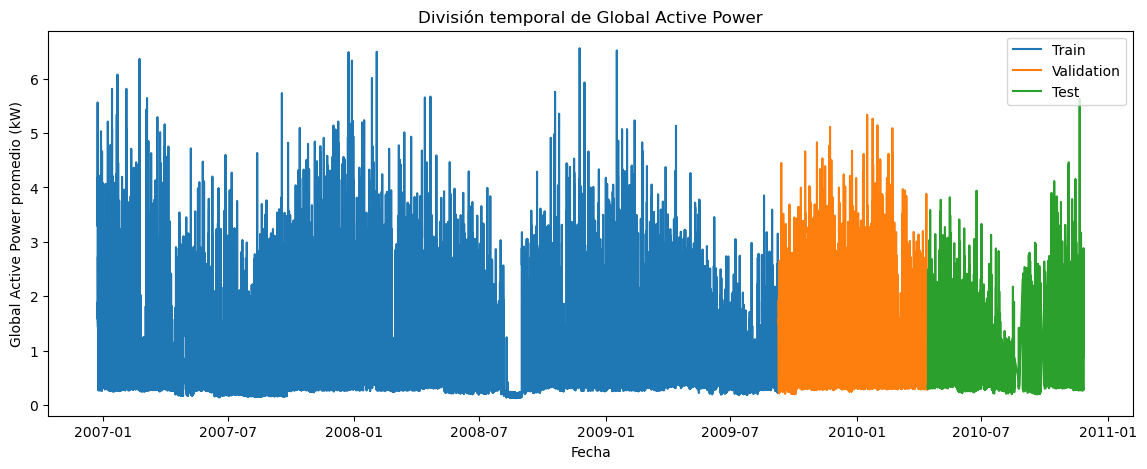

In [52]:
plt.figure(figsize=(14, 5))

plt.plot(
    train.index,
    train[target],
    label="Train"
)

plt.plot(
    validation.index,
    validation[target],
    label="Validation"
)

plt.plot(
    test.index,
    test[target],
    label="Test"
)

plt.title(
    "División temporal de Global Active Power"
)
plt.xlabel("Fecha")
plt.ylabel("Global Active Power promedio (kW)")
plt.legend()
plt.show()

Las variables históricas fueron construidas antes de la división, pero utilizan exclusivamente información correspondiente a instantes anteriores mediante shift() y ventanas móviles desplazadas. Por tanto, para cada predicción t, únicamente se emplea información disponible hasta t-1. Esta evaluación representa un esquema de forecasting de un paso hacia adelante, en el cual las observaciones reales se incorporan conforme transcurre el tiempo.

# 9. Baseline de forecasting

Antes de entrenar modelos de Machine Learning se establecerá un modelo
baseline que funcione como referencia mínima de desempeño.

Se utilizará un **Naive Persistence Forecast**, bajo el supuesto de que la
potencia activa promedio de la hora que se desea pronosticar será igual a la
observada durante la hora inmediatamente anterior.

Matemáticamente:

$$
\hat{y}_t = y_{t-1}
$$

Este baseline permitirá determinar posteriormente si los modelos de Machine
Learning aportan una mejora real respecto a una estrategia sencilla basada
únicamente en persistencia temporal.

### Función de evaluación

In [53]:
def evaluar_modelo(y_real, y_pred):
    mae = mean_absolute_error( # En promedio, ¿cuántos kW me separan del valor real?
        y_real,
        y_pred
    )

    rmse = np.sqrt( # Lo mismo que mae pero penalizando más los errores grandes
        mean_squared_error(
            y_real,
            y_pred
        )
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
    }

### Evaluación del baseline en Validation

In [54]:
y_val = validation[target]

pred_baseline_val = validation["lag_1"]

metricas_baseline = evaluar_modelo(
    y_val,
    pred_baseline_val
)

metricas_baseline

{'MAE': 0.4668620741577904, 'RMSE': np.float64(0.694722431079061)}

**Resultado del baseline:**
El modelo Naive Persistence Forecast obtuvo un MAE de 0.467 kW y un RMSE de 0.695 kW sobre el conjunto de validación. Estos valores constituyen la referencia mínima de desempeño para los modelos posteriores. Para considerar que un modelo de Machine Learning aporta valor predictivo, deberá demostrar una mejora frente a este baseline, principalmente mediante una reducción de MAE y RMSE.

## 9.1 Registro del baseline en MLflow

El baseline será registrado como el primer experimento formal del proyecto.
Aunque este modelo no posee hiperparámetros entrenables, se registrarán la
configuración del problema, la versión de los datos y las métricas obtenidas
para garantizar trazabilidad y permitir su comparación con los modelos
posteriores.

In [55]:
import mlflow

print("MLflow:", mlflow.__version__)

MLflow: 3.15.2


In [56]:
from src.tracking.mlflow_config import (
    setup_mlflow,
    DATA_VERSION,
)

setup_mlflow()

2026/08/28 10:30:46 INFO mlflow.tracking.fluent: Experiment with name 'household-power-forecasting' does not exist. Creating a new experiment.


### Resistro del Baseline

In [57]:
with mlflow.start_run(
    run_name="baseline_naive_persistence"
):

    mlflow.log_param(
        "algorithm",
        "NaivePersistence"
    )

    mlflow.log_param(
        "feature_set",
        "lag_1"
    )

    mlflow.log_param(
        "forecast_horizon",
        "t+1_hour"
    )

    mlflow.log_param(
        "frequency",
        "hourly"
    )

    mlflow.log_param(
        "data_version",
        DATA_VERSION
    )

    mlflow.log_param(
        "random_seed",
        "not_applicable"
    )

    mlflow.log_param(
        "hyperparameters",
        "none"
    )

    mlflow.log_metric(
        "MAE_validation",
        float(metricas_baseline["MAE"])
    )

    mlflow.log_metric(
        "RMSE_validation",
        float(metricas_baseline["RMSE"])
    )

🏃 View run baseline_naive_persistence at: http://127.0.0.1:5000/#/experiments/1/runs/d46761f5b7ff41ee8debd52b77ae59ac
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


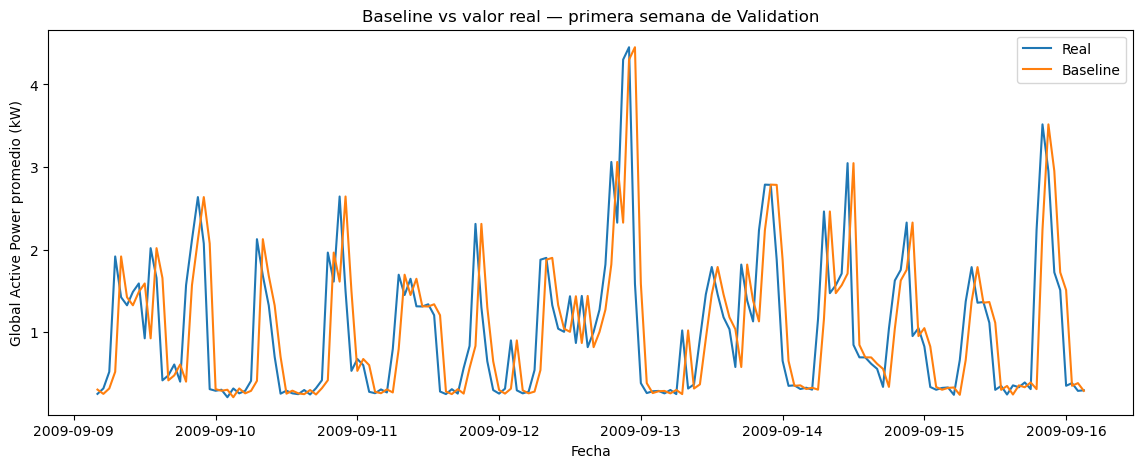

In [58]:
baseline_plot = validation[
    [target, "lag_1"]
].iloc[:24 * 7]

plt.figure(figsize=(14, 5))

plt.plot(
    baseline_plot.index,
    baseline_plot[target],
    label="Real"
)

plt.plot(
    baseline_plot.index,
    baseline_plot["lag_1"],
    label="Baseline"
)

plt.title(
    "Baseline vs valor real — primera semana de Validation"
)

plt.xlabel("Fecha")
plt.ylabel("Global Active Power promedio (kW)")
plt.legend()
plt.show()

# 10. Modelado y experimentación

Una vez establecido el baseline de forecasting, se entrenarán modelos de
Machine Learning con el objetivo de determinar si las características
construidas durante el Feature Engineering aportan capacidad predictiva
adicional.

La experimentación seguirá los siguientes principios:

- Los modelos se entrenarán exclusivamente con el conjunto `Train`.
- Las decisiones de modelado se tomarán utilizando `Validation`.
- El conjunto `Test` permanecerá reservado hasta seleccionar el modelo candidato final.
- Se compararán los Feature Sets A y B utilizando las mismas observaciones.
- Las métricas principales serán MAE y RMSE.
- El RMSE será utilizado como criterio principal de selección debido a que
  penaliza con mayor intensidad los errores grandes, relevantes en períodos
  de alta demanda eléctrica.
- Cada experimento será registrado en MLflow junto con sus parámetros,
  métricas, características, artefactos y modelo entrenado.

## 10.1 Criterio de comparación

El baseline Naive Persistence obtuvo sobre Validation:

- MAE: 0.467 kW
- RMSE: 0.695 kW

Un modelo será considerado superior al baseline si reduce sus errores de
validación. La selección del candidato se realizará principalmente mediante
el menor RMSE, utilizando MAE como métrica complementaria.

Si dos configuraciones presentan un desempeño prácticamente equivalente,
se favorecerá la alternativa más simple y reproducible.

## 10.2 Preparar X / y

In [59]:
X_train_a = train[features_a]
X_val_a = validation[features_a]

X_train_b = train[features_b]
X_val_b = validation[features_b]

y_train = train[target]
y_val = validation[target]

In [60]:
print("Feature Set A")
print("Train:", X_train_a.shape)
print("Validation:", X_val_a.shape)

print("\nFeature Set B")
print("Train:", X_train_b.shape)
print("Validation:", X_val_b.shape)

print("\nTarget")
print("Train:", y_train.shape)
print("Validation:", y_val.shape)

Feature Set A
Train: (23236, 10)
Validation: (4979, 10)

Feature Set B
Train: (23236, 13)
Validation: (4979, 13)

Target
Train: (23236,)
Validation: (4979,)


## 10.4 Función para calcular mejora frente al baseline

In [61]:
def calcular_mejora_porcentual(valor_baseline, valor_modelo):
    return (
        (valor_baseline - valor_modelo)
        / valor_baseline
        * 100
    )

## 10.5 Creación de estructura para guardar los resultados

In [62]:
resultados_modelos = []

# 11. Linear Regression 

La Regresión Lineal se utiliza como primer modelo de Machine Learning debido
a su simplicidad e interpretabilidad.

Su objetivo será determinar hasta qué punto las variables temporales,
rezagos y estadísticas construidas permiten explicar el comportamiento
horario de `Global_active_power` mediante relaciones lineales.

Las variables serán estandarizadas utilizando únicamente los datos de
entrenamiento. La transformación y el modelo se encapsularán mediante un
`Pipeline` para evitar inconsistencias entre entrenamiento e inferencia.

## 11.1 Linear Regression - Feature Set A


### Modelo

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [64]:
modelo_lr_a = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LinearRegression()
    ),
])

**Entrenamiento**

In [65]:
modelo_lr_a.fit(
    X_train_a,
    y_train
)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


**Predicción**

In [66]:
pred_lr_a = modelo_lr_a.predict(
    X_val_a
)

**Evaluación**

In [67]:
metricas_lr_a = evaluar_modelo(
    y_val,
    pred_lr_a
)

metricas_lr_a

{'MAE': 0.4234878697755057, 'RMSE': np.float64(0.5936699268787204)}

### Calcular mejora frente a baseline

In [68]:
mejora_mae_lr_a = calcular_mejora_porcentual(
    metricas_baseline["MAE"],
    metricas_lr_a["MAE"]
)

mejora_rmse_lr_a = calcular_mejora_porcentual(
    metricas_baseline["RMSE"],
    metricas_lr_a["RMSE"]
)

print(
    "Mejora MAE:",
    round(mejora_mae_lr_a, 2),
    "%"
)

print(
    "Mejora RMSE:",
    round(mejora_rmse_lr_a, 2),
    "%"
)

Mejora MAE: 9.29 %
Mejora RMSE: 14.55 %


### Guardar el resultado

In [69]:
resultados_modelos.append({
    "Modelo": "LinearRegression",
    "Feature_Set": "A",
    "MAE": metricas_lr_a["MAE"],
    "RMSE": metricas_lr_a["RMSE"],
    "Mejora_MAE_%": mejora_mae_lr_a,
    "Mejora_RMSE_%": mejora_rmse_lr_a,
})

### Registrar Linear Regression A en MLflow

In [70]:
import mlflow.sklearn

from mlflow.models import infer_signature

In [71]:
# ==========================================
# Registro Linear Regression A en MLflow
# ==========================================

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

# Asegurar que no haya otro run abierto
if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(
    run_name="linear_regression_feature_set_a"
):

    # ==========================================
    # PARÁMETROS
    # ==========================================

    mlflow.log_param(
        "algorithm",
        "LinearRegression"
    )

    mlflow.log_param(
        "feature_set",
        "A"
    )

    mlflow.log_param(
        "n_features",
        len(features_a)
    )

    mlflow.log_param(
        "forecast_horizon",
        "t+1_hour"
    )

    mlflow.log_param(
        "frequency",
        "hourly"
    )

    mlflow.log_param(
        "data_version",
        DATA_VERSION
    )

    mlflow.log_param(
        "random_seed",
        "not_applicable"
    )

    mlflow.log_param(
        "scaler",
        "StandardScaler"
    )

    mlflow.log_param(
        "fit_intercept",
        modelo_lr_a.named_steps["model"].fit_intercept
    )

    mlflow.log_param(
        "train_start",
        str(train.index.min())
    )

    mlflow.log_param(
        "train_end",
        str(train.index.max())
    )

    mlflow.log_param(
        "validation_start",
        str(validation.index.min())
    )

    mlflow.log_param(
        "validation_end",
        str(validation.index.max())
    )

    # ==========================================
    # MÉTRICAS
    # ==========================================

    mlflow.log_metric(
        "MAE_validation",
        float(metricas_lr_a["MAE"])
    )

    mlflow.log_metric(
        "RMSE_validation",
        float(metricas_lr_a["RMSE"])
    )

    mlflow.log_metric(
        "MAE_improvement_pct",
        float(mejora_mae_lr_a)
    )

    mlflow.log_metric(
        "RMSE_improvement_pct",
        float(mejora_rmse_lr_a)
    )

    # ==========================================
    # FEATURES
    # ==========================================

    mlflow.log_dict(
        {
            "features": features_a
        },
        "metadata/features.json"
    )

    # ==========================================
    # REAL VS PREDICCIÓN
    # ==========================================

    muestra_lr_a = validation.iloc[:24 * 7]

    pred_lr_a_series = pd.Series(
        pred_lr_a,
        index=validation.index
    )

    fig, ax = plt.subplots(
        figsize=(14, 5)
    )

    ax.plot(
        muestra_lr_a.index,
        muestra_lr_a[target],
        label="Real"
    )

    ax.plot(
        muestra_lr_a.index,
        pred_lr_a_series.loc[muestra_lr_a.index],
        label="Predicción"
    )

    ax.set_title(
        "Linear Regression A — Real vs Predicción"
    )

    ax.set_xlabel("Fecha")

    ax.set_ylabel(
        "Global Active Power promedio (kW)"
    )

    ax.legend()

    mlflow.log_figure(
        fig,
        "plots/forecast_validation.png"
    )

    plt.close(fig)

    # ==========================================
    # RESIDUALES
    # ==========================================

    residuos_lr_a = (
        y_val.to_numpy()
        - pred_lr_a
    )

    fig_res, ax = plt.subplots(
        figsize=(10, 5)
    )

    ax.scatter(
        pred_lr_a,
        residuos_lr_a,
        alpha=0.3
    )

    ax.axhline(
        0,
        linestyle="--"
    )

    ax.set_title(
        "Linear Regression A — Residuales"
    )

    ax.set_xlabel(
        "Valor predicho"
    )

    ax.set_ylabel(
        "Residual"
    )

    mlflow.log_figure(
        fig_res,
        "plots/residuals_validation.png"
    )

    plt.close(fig_res)

    # ==========================================
    # MODELO
    # ==========================================

    ejemplo_lr_a = X_train_a.head(20)

    signature_lr_a = infer_signature(
        ejemplo_lr_a,
        modelo_lr_a.predict(ejemplo_lr_a)
    )

    mlflow.sklearn.log_model(
        sk_model=modelo_lr_a,
        name="model",
        signature=signature_lr_a,
        input_example=X_train_a.head(5)
    )

print(
    "Linear Regression A registrado correctamente en MLflow."
)

c:\Users\hijad\anaconda3\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run linear_regression_feature_set_a at: http://127.0.0.1:5000/#/experiments/1/runs/4adf9c1ea2af4257bdc106a8a691b190
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Linear Regression A registrado correctamente en MLflow.


### Artefacto: predicción vs realidad



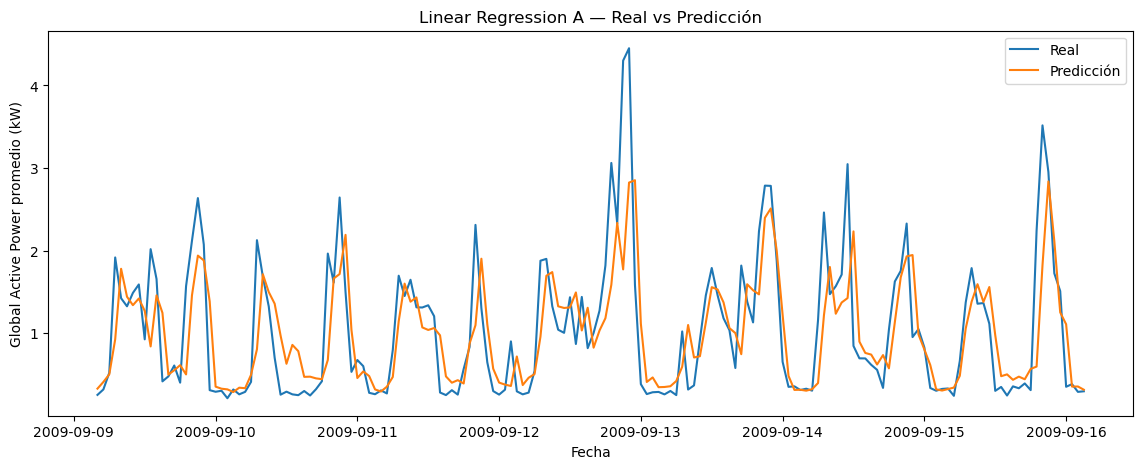

In [72]:
muestra_lr_a = validation.iloc[:24 * 7]

fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    muestra_lr_a.index,
    muestra_lr_a[target],
    label="Real"
)

ax.plot(
    muestra_lr_a.index,
    pred_lr_a[:24 * 7],
    label="Predicción"
)

ax.set_title(
    "Linear Regression A — Real vs Predicción"
)

ax.set_xlabel("Fecha")
ax.set_ylabel(
    "Global Active Power promedio (kW)"
)

ax.legend()

### Artefacto: residual plot

In [73]:
residuos_lr_a = (
    y_val.values
    - pred_lr_a
)

Text(0, 0.5, 'Residual')

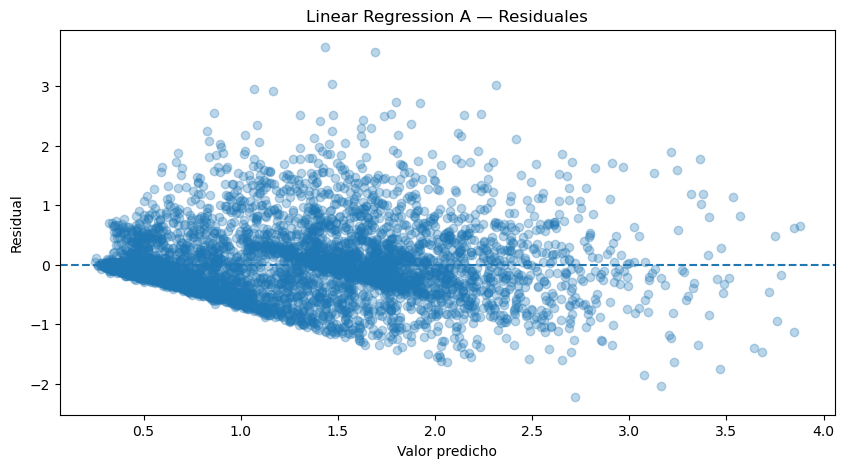

In [74]:
fig_res, ax = plt.subplots(
    figsize=(10, 5)
)

ax.scatter(
    pred_lr_a,
    residuos_lr_a,
    alpha=0.3
)

ax.axhline(
    0,
    linestyle="--"
)

ax.set_title(
    "Linear Regression A — Residuales"
)

ax.set_xlabel(
    "Valor predicho"
)

ax.set_ylabel(
    "Residual"
)

## 11.2 Linear Regression — Feature Set B

### Modelo

In [75]:
modelo_lr_b = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LinearRegression()
    ),
])

**Entrenamiento**

In [76]:
modelo_lr_b.fit(
    X_train_b,
    y_train
)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


**Predicción**

In [77]:
pred_lr_b = modelo_lr_b.predict(
    X_val_b
)

**Evaluación**

In [78]:
metricas_lr_b = evaluar_modelo(
    y_val,
    pred_lr_b
)

### Calcular mejora frente a baseline

In [79]:
mejora_mae_lr_b = calcular_mejora_porcentual(
    metricas_baseline["MAE"],
    metricas_lr_b["MAE"]
)

mejora_rmse_lr_b = calcular_mejora_porcentual(
    metricas_baseline["RMSE"],
    metricas_lr_b["RMSE"]
)

print(
    "Mejora MAE:",
    round(mejora_mae_lr_b, 2),
    "%"
)

print(
    "Mejora RMSE:",
    round(mejora_rmse_lr_b, 2),
    "%"
)

Mejora MAE: 9.29 %
Mejora RMSE: 15.04 %


### Guardar los resultados

In [80]:
resultados_modelos.append({
    "Modelo": "LinearRegression",
    "Feature_Set": "B",
    "MAE": metricas_lr_b["MAE"],
    "RMSE": metricas_lr_b["RMSE"],
    "Mejora_MAE_%": mejora_mae_lr_b,
    "Mejora_RMSE_%": mejora_rmse_lr_b,
})

### Registrar Linear Regression B en MLFlow

In [81]:
# Métricas de Train para analizar posible sobreajuste
pred_lr_b_train = modelo_lr_b.predict(X_train_b)

metricas_lr_b_train = evaluar_modelo(
    y_train,
    pred_lr_b_train
)

# Asegurar que no haya otro run abierto
if mlflow.active_run() is not None:
    mlflow.end_run()


with mlflow.start_run(
    run_name="linear_regression_feature_set_b"
):

    # =========================
    # PARÁMETROS
    # =========================

    mlflow.log_param(
        "algorithm",
        "LinearRegression"
    )

    mlflow.log_param(
        "feature_set",
        "B"
    )

    mlflow.log_param(
        "n_features",
        len(features_b)
    )

    mlflow.log_param(
        "forecast_horizon",
        "t+1_hour"
    )

    mlflow.log_param(
        "frequency",
        "hourly"
    )

    mlflow.log_param(
        "data_version",
        DATA_VERSION
    )

    mlflow.log_param(
        "random_seed",
        "not_applicable"
    )

    mlflow.log_param(
        "scaler",
        "StandardScaler"
    )

    mlflow.log_param(
        "fit_intercept",
        modelo_lr_b.named_steps["model"].fit_intercept
    )

    mlflow.log_param(
        "train_start",
        str(train.index.min())
    )

    mlflow.log_param(
        "train_end",
        str(train.index.max())
    )

    mlflow.log_param(
        "validation_start",
        str(validation.index.min())
    )

    mlflow.log_param(
        "validation_end",
        str(validation.index.max())
    )

    # =========================
    # MÉTRICAS
    # =========================

    mlflow.log_metric(
        "MAE_train",
        float(metricas_lr_b_train["MAE"])
    )

    mlflow.log_metric(
        "RMSE_train",
        float(metricas_lr_b_train["RMSE"])
    )

    mlflow.log_metric(
        "MAE_validation",
        float(metricas_lr_b["MAE"])
    )

    mlflow.log_metric(
        "RMSE_validation",
        float(metricas_lr_b["RMSE"])
    )

    mlflow.log_metric(
        "MAE_improvement_pct",
        float(mejora_mae_lr_b)
    )

    mlflow.log_metric(
        "RMSE_improvement_pct",
        float(mejora_rmse_lr_b)
    )

    # =========================
    # FEATURES
    # =========================

    mlflow.log_dict(
        {
            "features": features_b
        },
        "metadata/features.json"
    )

    # =========================
    # REAL VS PREDICCIÓN
    # =========================

    muestra = validation.iloc[:24 * 7]

    pred_lr_b_series = pd.Series(
        pred_lr_b,
        index=validation.index
    )

    fig, ax = plt.subplots(
        figsize=(14, 5)
    )

    ax.plot(
        muestra.index,
        muestra[target],
        label="Real"
    )

    ax.plot(
        muestra.index,
        pred_lr_b_series.loc[muestra.index],
        label="Predicción"
    )

    ax.set_title(
        "Linear Regression B — Real vs Predicción"
    )

    ax.set_xlabel("Fecha")

    ax.set_ylabel(
        "Global Active Power promedio (kW)"
    )

    ax.legend()

    mlflow.log_figure(
        fig,
        "plots/forecast_validation.png"
    )

    plt.close(fig)

    # =========================
    # RESIDUALES
    # =========================

    residuos_lr_b = (
        y_val.to_numpy()
        - pred_lr_b
    )

    fig_res, ax = plt.subplots(
        figsize=(10, 5)
    )

    ax.scatter(
        pred_lr_b,
        residuos_lr_b,
        alpha=0.3
    )

    ax.axhline(
        0,
        linestyle="--"
    )

    ax.set_title(
        "Linear Regression B — Residuales"
    )

    ax.set_xlabel("Valor predicho")
    ax.set_ylabel("Residual")

    mlflow.log_figure(
        fig_res,
        "plots/residuals_validation.png"
    )

    plt.close(fig_res)

    # =========================
    # MODELO
    # =========================

    ejemplo_lr_b = X_train_b.head(20)

    signature_lr_b = infer_signature(
        ejemplo_lr_b,
        modelo_lr_b.predict(ejemplo_lr_b)
    )

    mlflow.sklearn.log_model(
        sk_model=modelo_lr_b,
        name="model",
        signature=signature_lr_b,
        input_example=X_train_b.head(5),
    )

print(
    "Linear Regression B registrado correctamente en MLflow."
)

c:\Users\hijad\anaconda3\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run linear_regression_feature_set_b at: http://127.0.0.1:5000/#/experiments/1/runs/474eb3dcf8c44435a999de43ff1ffd03
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Linear Regression B registrado correctamente en MLflow.


# 12. Random Forest 

Random Forest se evaluará como segundo algoritmo debido a su capacidad para
modelar relaciones no lineales e interacciones entre variables sin requerir
una relación funcional lineal entre los predictores y el target.

A diferencia de la Regresión Lineal, Random Forest no requiere
estandarización de las variables.

Se utilizará inicialmente una configuración controlada y reproducible,
manteniendo `random_state=42`.

In [82]:
from sklearn.ensemble import RandomForestRegressor

In [83]:
modelo_rf_a = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

## 12.1 Random Forest - Feature Set A

**Entrenamiento**

In [84]:
modelo_rf_a.fit(
    X_train_a,
    y_train
)

,n_estimators,300
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Predicción**

In [85]:
pred_rf_a = modelo_rf_a.predict(
    X_val_a
)

**Evaluación**

In [86]:
metricas_rf_a = evaluar_modelo(
    y_val,
    pred_rf_a
)

metricas_rf_a

{'MAE': 0.38327684472447804, 'RMSE': np.float64(0.5523817920836771)}

### Calcular la mejora frente a baseline

In [87]:
mejora_mae_rf_a = calcular_mejora_porcentual(
    metricas_baseline["MAE"],
    metricas_rf_a["MAE"]
)

mejora_rmse_rf_a = calcular_mejora_porcentual(
    metricas_baseline["RMSE"],
    metricas_rf_a["RMSE"]
)

print(
    "Mejora MAE Random Forest A:",
    round(mejora_mae_rf_a, 2),
    "%"
)

print(
    "Mejora RMSE Random Forest A:",
    round(mejora_rmse_rf_a, 2),
    "%"
)

Mejora MAE Random Forest A: 17.9 %
Mejora RMSE Random Forest A: 20.49 %


### Guardar los resultados

In [88]:
resultados_modelos.append({
    "Modelo": "RandomForest",
    "Feature_Set": "A",
    "MAE": metricas_rf_a["MAE"],
    "RMSE": metricas_rf_a["RMSE"],
    "Mejora_MAE_%": mejora_mae_rf_a,
    "Mejora_RMSE_%": mejora_rmse_rf_a,
})

## 12.2 Random Forest - Feature Set B

### Modelo

In [89]:
modelo_rf_b = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

**Entrenamiento**

In [90]:
modelo_rf_b.fit(
    X_train_b,
    y_train
)

,n_estimators,300
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Predicción**

In [91]:
pred_rf_b = modelo_rf_b.predict(
    X_val_b
)


**Evaluación**

In [92]:
metricas_rf_b = evaluar_modelo(
    y_val,
    pred_rf_b
)

metricas_rf_b

{'MAE': 0.3759661399922781, 'RMSE': np.float64(0.5433063094640981)}

### Calcular la mejora frente al baseline

In [93]:
mejora_mae_rf_b = calcular_mejora_porcentual(
    metricas_baseline["MAE"],
    metricas_rf_b["MAE"]
)

mejora_rmse_rf_b = calcular_mejora_porcentual(
    metricas_baseline["RMSE"],
    metricas_rf_b["RMSE"]
)

print(
    "Mejora MAE Random Forest B:",
    round(mejora_mae_rf_b, 2),
    "%"
)

print(
    "Mejora RMSE Random Forest B:",
    round(mejora_rmse_rf_b, 2),
    "%"
)

Mejora MAE Random Forest B: 19.47 %
Mejora RMSE Random Forest B: 21.8 %


### Guardar los resultados

In [94]:
resultados_modelos.append({
    "Modelo": "RandomForest",
    "Feature_Set": "B",
    "MAE": metricas_rf_b["MAE"],
    "RMSE": metricas_rf_b["RMSE"],
    "Mejora_MAE_%": mejora_mae_rf_b,
    "Mejora_RMSE_%": mejora_rmse_rf_b,
})

In [95]:
resultados_df = pd.DataFrame(
    resultados_modelos
)

In [96]:
baseline_row = pd.DataFrame([
    {
        "Modelo": "NaivePersistence",
        "Feature_Set": "lag_1",
        "MAE": metricas_baseline["MAE"],
        "RMSE": metricas_baseline["RMSE"],
        "Mejora_MAE_%": 0.0,
        "Mejora_RMSE_%": 0.0,
    }
])

In [97]:
comparacion_modelos = pd.concat(
    [
        baseline_row,
        resultados_df,
    ],
    ignore_index=True,
)

In [98]:
comparacion_modelos = (
    comparacion_modelos
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(comparacion_modelos)

,Modelo,Feature_Set,MAE,RMSE,Mejora_MAE_%,Mejora_RMSE_%
0,RandomForest,B,0.375966,0.543306,19.469548,21.795197
1,RandomForest,A,0.383277,0.552382,17.903624,20.488850
2,LinearRegression,B,0.423485,0.590239,9.291189,15.039535
3,LinearRegression,A,0.423488,0.593670,9.290582,14.545738
4,NaivePersistence,lag_1,0.466862,0.694722,0.000000,0.000000


**¿Qué características utilizó más para realizar sus predicciones?**

In [99]:
importancia_rf_b = pd.DataFrame({
    "Feature": features_b,
    "Importance": modelo_rf_b.feature_importances_,
})

importancia_rf_b = (
    importancia_rf_b
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(importancia_rf_b)

,Feature,Importance
0,lag_1,0.617966
1,lag_168,0.070272
2,lag_24,0.057335
3,rolling_mean_3,0.045004
4,hour_cos,0.043676
5,hour_sin,0.039384
6,rolling_mean_24,0.036336
7,rolling_std_24,0.033942
8,month_cos,0.017634
9,day_of_week_sin,0.015911


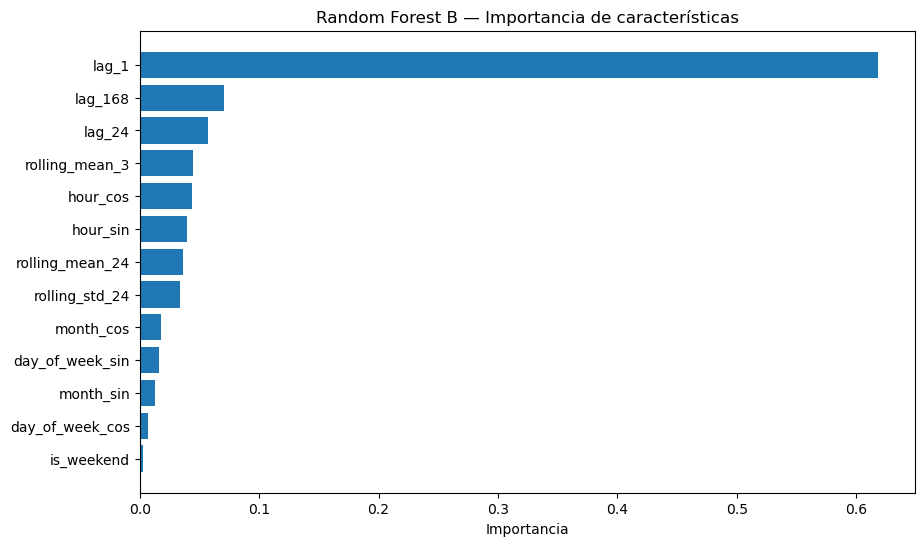

In [100]:
plt.figure(figsize=(10, 6))

plt.barh(
    importancia_rf_b["Feature"],
    importancia_rf_b["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Random Forest B — Importancia de características"
)

plt.xlabel("Importancia")
plt.show()

Interpretación del Feature Importance — Random Forest B:
La característica dominante es lag_1, con aproximadamente 61.8% de importancia, lo que confirma la fuerte dependencia del consumo eléctrico respecto a la hora inmediatamente anterior. Los rezagos lag_24 y lag_168 también presentan una contribución relevante, evidenciando que los patrones diarios y semanales contienen información predictiva.

Las rolling features concentran conjuntamente aproximadamente 11.6% de la importancia, respaldando la mejora observada al pasar del Feature Set A al Feature Set B. Las variables cíclicas asociadas a la hora aportan adicionalmente información sobre el patrón intradiario del consumo.

En conjunto, los resultados muestran que el modelo se apoya principalmente en la memoria reciente de la serie, complementándola con patrones diarios, semanales y estadísticas del comportamiento reciente. Estas importancias no deben interpretarse como relaciones causales y pueden verse repartidas entre variables correlacionadas.

### Interpretación de la comparación inicial de modelos

Los cuatro modelos de Machine Learning evaluados superaron al baseline Naive
Persistence tanto en MAE como en RMSE. Este resultado indica que las
características construidas durante el Feature Engineering aportan información
predictiva adicional respecto a utilizar únicamente el valor observado durante
la hora anterior.

La Regresión Lineal obtuvo mejoras de aproximadamente 9.29% en MAE y entre
14.55% y 15.04% en RMSE frente al baseline. Sin embargo, la diferencia entre
los Feature Sets A y B fue muy reducida, lo que indica que la incorporación
de estadísticas móviles aporta poca mejora cuando las relaciones se modelan
de forma exclusivamente lineal.

Random Forest presentó un desempeño superior a la Regresión Lineal. El Feature
Set A redujo el RMSE en 20.53% respecto al baseline, mientras que el Feature
Set B alcanzó una reducción de 21.83%.

Dentro de Random Forest, la incorporación de las rolling features del Feature
Set B produjo una mejora adicional de aproximadamente 1.64% en RMSE y 1.89%
en MAE respecto al Feature Set A. Esto sugiere que el contexto agregado de las
horas recientes aporta información útil cuando el modelo puede representar
relaciones no lineales e interacciones entre variables.

La mejor configuración inicial es Random Forest con Feature Set B, con:

- MAE de Validation: 0.376 kW
- RMSE de Validation: 0.543 kW
- Mejora de MAE frente al baseline: 19.54%
- Mejora de RMSE frente al baseline: 21.83%

Esta configuración se considerará el candidato principal para la siguiente
etapa de experimentación. El conjunto Test permanecerá sin utilizar hasta
completar la selección y ajuste del modelo.

12.3 Registro de Random Forest A

Se registra en MLflow el primer modelo de Random Forest utilizando el Feature Set A. Se almacenan parámetros, métricas de entrenamiento y validación, características utilizadas, gráficos y el modelo entrenado.

In [101]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

# ------------------------------------------
# Métricas de Train
# ------------------------------------------

pred_rf_a_train = modelo_rf_a.predict(X_train_a)

metricas_rf_a_train = evaluar_modelo(
    y_train,
    pred_rf_a_train
)

print("Random Forest A - Train")
print("MAE:", metricas_rf_a_train["MAE"])
print("RMSE:", metricas_rf_a_train["RMSE"])


# ------------------------------------------
# Registro en MLflow
# ------------------------------------------

if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(
    run_name="random_forest_feature_set_a"
):

    # Parámetros
    mlflow.log_param("algorithm", "RandomForestRegressor")
    mlflow.log_param("feature_set", "A")
    mlflow.log_param("n_features", len(features_a))
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 15)
    mlflow.log_param("min_samples_leaf", 2)
    mlflow.log_param("random_seed", 42)
    mlflow.log_param("n_jobs", -1)
    mlflow.log_param("forecast_horizon", "t+1_hour")
    mlflow.log_param("frequency", "hourly")
    mlflow.log_param("data_version", DATA_VERSION)

    mlflow.log_param(
        "train_start",
        str(train.index.min())
    )

    mlflow.log_param(
        "train_end",
        str(train.index.max())
    )

    mlflow.log_param(
        "validation_start",
        str(validation.index.min())
    )

    mlflow.log_param(
        "validation_end",
        str(validation.index.max())
    )

    # Métricas
    mlflow.log_metric(
        "MAE_train",
        float(metricas_rf_a_train["MAE"])
    )

    mlflow.log_metric(
        "RMSE_train",
        float(metricas_rf_a_train["RMSE"])
    )

    mlflow.log_metric(
        "MAE_validation",
        float(metricas_rf_a["MAE"])
    )

    mlflow.log_metric(
        "RMSE_validation",
        float(metricas_rf_a["RMSE"])
    )

    mlflow.log_metric(
        "MAE_improvement_pct",
        float(mejora_mae_rf_a)
    )

    mlflow.log_metric(
        "RMSE_improvement_pct",
        float(mejora_rmse_rf_a)
    )

    # Features
    mlflow.log_dict(
        {
            "features": features_a
        },
        "metadata/features.json"
    )

    # Modelo
    ejemplo_rf_a = X_train_a.head(20)

    signature_rf_a = infer_signature(
        ejemplo_rf_a,
        modelo_rf_a.predict(ejemplo_rf_a)
    )

    mlflow.sklearn.log_model(
        sk_model=modelo_rf_a,
        name="model",
        signature=signature_rf_a,
        input_example=X_train_a.head(5)
    )

print("Random Forest A registrado correctamente en MLflow.")

Random Forest A - Train
MAE: 0.2222248851112594
RMSE: 0.32805191470389006


c:\Users\hijad\anaconda3\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run random_forest_feature_set_a at: http://127.0.0.1:5000/#/experiments/1/runs/5ce2c6164f0045ffb514dc9a805d18b8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Random Forest A registrado correctamente en MLflow.


El Random Forest A presenta un error promedio de aproximadamente 0.2222 kW según MAE sobre los datos de entrenamiento. El RMSE de 0.3281 kW indica que, aunque existen algunos errores mayores, el modelo mantiene un desempeño razonable sobre Train.

Estos valores corresponden únicamente al conjunto de entrenamiento, por lo que todavía no permiten determinar si existe overfitting. Para eso debemos comparar posteriormente estas métricas con las obtenidas sobre Validation.

12.4 Registro de Random Forest B

Se registra Random Forest B, construido con el Feature Set B, que previamente mostró mejor desempeño que Random Forest A.

In [102]:
pred_rf_b_train = modelo_rf_b.predict(X_train_b)

metricas_rf_b_train = evaluar_modelo(
    y_train,
    pred_rf_b_train
)

print("Random Forest B - Train")
print("MAE:", metricas_rf_b_train["MAE"])
print("RMSE:", metricas_rf_b_train["RMSE"])


if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(
    run_name="random_forest_feature_set_b"
):

    # Parámetros
    mlflow.log_param("algorithm", "RandomForestRegressor")
    mlflow.log_param("feature_set", "B")
    mlflow.log_param("n_features", len(features_b))
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 15)
    mlflow.log_param("min_samples_leaf", 2)
    mlflow.log_param("random_seed", 42)
    mlflow.log_param("n_jobs", -1)
    mlflow.log_param("forecast_horizon", "t+1_hour")
    mlflow.log_param("frequency", "hourly")
    mlflow.log_param("data_version", DATA_VERSION)

    mlflow.log_param(
        "train_start",
        str(train.index.min())
    )

    mlflow.log_param(
        "train_end",
        str(train.index.max())
    )

    mlflow.log_param(
        "validation_start",
        str(validation.index.min())
    )

    mlflow.log_param(
        "validation_end",
        str(validation.index.max())
    )

    # Métricas
    mlflow.log_metric(
        "MAE_train",
        float(metricas_rf_b_train["MAE"])
    )

    mlflow.log_metric(
        "RMSE_train",
        float(metricas_rf_b_train["RMSE"])
    )

    mlflow.log_metric(
        "MAE_validation",
        float(metricas_rf_b["MAE"])
    )

    mlflow.log_metric(
        "RMSE_validation",
        float(metricas_rf_b["RMSE"])
    )

    mlflow.log_metric(
        "MAE_improvement_pct",
        float(mejora_mae_rf_b)
    )

    mlflow.log_metric(
        "RMSE_improvement_pct",
        float(mejora_rmse_rf_b)
    )

    # Features
    mlflow.log_dict(
        {
            "features": features_b
        },
        "metadata/features.json"
    )

    # Modelo
    ejemplo_rf_b = X_train_b.head(20)

    signature_rf_b = infer_signature(
        ejemplo_rf_b,
        modelo_rf_b.predict(ejemplo_rf_b)
    )

    mlflow.sklearn.log_model(
        sk_model=modelo_rf_b,
        name="model",
        signature=signature_rf_b,
        input_example=X_train_b.head(5)
    )

print("Random Forest B registrado correctamente en MLflow.")

Random Forest B - Train
MAE: 0.21396688315929188
RMSE: 0.31558608929772375


c:\Users\hijad\anaconda3\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run random_forest_feature_set_b at: http://127.0.0.1:5000/#/experiments/1/runs/515ec4ddf30c407a9ccaf5652115ee14
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Random Forest B registrado correctamente en MLflow.


Random Forest B obtuvo un MAE de 0.2140 kW y un RMSE de 0.3156 kW sobre el conjunto de entrenamiento, mostrando un desempeño ligeramente superior al Random Forest A. No obstante, esta comparación por sí sola no es suficiente para seleccionar el modelo, por lo que posteriormente se analizarán las métricas de Validation y la diferencia entre Train y Validation para evaluar su capacidad de generalización.

12.5 Análisis de overfitting de Random Forest

Se comparan las métricas obtenidas en Train y Validation. Una diferencia grande entre ambos conjuntos puede indicar sobreajuste.

In [103]:
# ==========================================
# 12.5 Análisis de overfitting
# ==========================================

print("Random Forest A")
print("----------------")

print(
    "MAE Train:",
    metricas_rf_a_train["MAE"]
)

print(
    "MAE Validation:",
    metricas_rf_a["MAE"]
)

print(
    "Diferencia MAE:",
    metricas_rf_a["MAE"] -
    metricas_rf_a_train["MAE"]
)

print()

print(
    "RMSE Train:",
    metricas_rf_a_train["RMSE"]
)

print(
    "RMSE Validation:",
    metricas_rf_a["RMSE"]
)

print(
    "Diferencia RMSE:",
    metricas_rf_a["RMSE"] -
    metricas_rf_a_train["RMSE"]
)


print("\nRandom Forest B")
print("----------------")

print(
    "MAE Train:",
    metricas_rf_b_train["MAE"]
)

print(
    "MAE Validation:",
    metricas_rf_b["MAE"]
)

print(
    "Diferencia MAE:",
    metricas_rf_b["MAE"] -
    metricas_rf_b_train["MAE"]
)

print()

print(
    "RMSE Train:",
    metricas_rf_b_train["RMSE"]
)

print(
    "RMSE Validation:",
    metricas_rf_b["RMSE"]
)

print(
    "Diferencia RMSE:",
    metricas_rf_b["RMSE"] -
    metricas_rf_b_train["RMSE"]
)

Random Forest A
----------------
MAE Train: 0.2222248851112594
MAE Validation: 0.38327684472447804
Diferencia MAE: 0.16105195961321864

RMSE Train: 0.32805191470389006
RMSE Validation: 0.5523817920836771
Diferencia RMSE: 0.22432987737978705

Random Forest B
----------------
MAE Train: 0.21396688315929188
MAE Validation: 0.3759661399922781
Diferencia MAE: 0.16199925683298624

RMSE Train: 0.31558608929772375
RMSE Validation: 0.5433063094640981
Diferencia RMSE: 0.22772022016637433


Ambos modelos presentan una diferencia entre las métricas de Train y Validation, lo que evidencia cierto grado de overfitting. No obstante, Random Forest B presenta menores errores de validación que Random Forest A, por lo que muestra un mejor desempeño de generalización dentro de esta comparación inicial. Debido a la diferencia observada entre Train y Validation, se realizará una segunda ronda de experimentación utilizando TimeSeriesSplit sobre Random Forest B, con el objetivo de evaluar configuraciones alternativas de hiperparámetros y buscar una configuración con mejor capacidad de generalización.

13. Optimización de Random Forest B

13.1 Segunda ronda de experimentación: TimeSeriesSplit

Como los datos corresponden a una serie temporal, se utiliza TimeSeriesSplit para evaluar diferentes configuraciones respetando el orden temporal.
Esta segunda ronda se realiza únicamente sobre Random Forest B.

In [104]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(
    n_splits=5
)

print(
    "Número de divisiones:",
    tscv.n_splits
)

Número de divisiones: 5


Se establecieron 5 divisiones mediante TimeSeriesSplit para realizar la validación interna de las configuraciones de Random Forest B. Esta estrategia mantiene el orden cronológico de las observaciones, evitando mezclar información futura con información pasada y proporcionando una evaluación más apropiada para una serie temporal.

13.2 Configuraciones de hiperparámetros

In [105]:
configuraciones_rf = [

    {
        "n_estimators": 200,
        "max_depth": 10,
        "min_samples_leaf": 2
    },

    {
        "n_estimators": 300,
        "max_depth": 15,
        "min_samples_leaf": 2
    },

    {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 2
    },

    {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 2
    }
]

print(
    "Configuraciones a evaluar:",
    len(configuraciones_rf)
)

for i, config in enumerate(
    configuraciones_rf,
    start=1
):

    print(
        f"Configuración {i}:",
        config
    )

Configuraciones a evaluar: 4
Configuración 1: {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 2}
Configuración 2: {'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 2}
Configuración 3: {'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 2}
Configuración 4: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 2}


Se definieron cuatro configuraciones de Random Forest B para evaluar el efecto de diferentes niveles de complejidad del modelo. Se modificaron n_estimators y max_depth, manteniendo min_samples_leaf=2 y random_state=42. Las configuraciones serán evaluadas mediante TimeSeriesSplit, utilizando MAE y RMSE promedio como criterios de comparación.

13.3 Evaluación de hiperparámetros con TimeSeriesSplit

In [106]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.ensemble import RandomForestRegressor

import numpy as np
import pandas as pd


resultados_tscv = []


for i, config in enumerate(
    configuraciones_rf,
    start=1
):

    mae_folds = []
    rmse_folds = []

    for train_idx, val_idx in tscv.split(X_train_b):

        X_fold_train = X_train_b.iloc[train_idx]
        X_fold_val = X_train_b.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        modelo = RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            random_state=42,
            n_jobs=-1
        )

        modelo.fit(
            X_fold_train,
            y_fold_train
        )

        pred_fold = modelo.predict(
            X_fold_val
        )

        mae = mean_absolute_error(
            y_fold_val,
            pred_fold
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_fold_val,
                pred_fold
            )
        )

        mae_folds.append(mae)
        rmse_folds.append(rmse)

    resultados_tscv.append({

        "Configuracion": i,

        "n_estimators":
            config["n_estimators"],

        "max_depth":
            config["max_depth"],

        "min_samples_leaf":
            config["min_samples_leaf"],

        "MAE_promedio":
            np.mean(mae_folds),

        "RMSE_promedio":
            np.mean(rmse_folds)
    })


resultados_tscv_df = pd.DataFrame(
    resultados_tscv
)

display(resultados_tscv_df)

,Configuracion,n_estimators,max_depth,min_samples_leaf,MAE_promedio,RMSE_promedio
0,1,200,10.0,2,0.384811,0.556058
1,2,300,15.0,2,0.388704,0.557899
2,3,300,20.0,2,0.390119,0.558608
3,4,300,NaN,2,0.390328,0.558746


La evaluación mediante TimeSeriesSplit muestra que la Configuración 1 obtuvo el menor MAE promedio (0.384811) y el menor RMSE promedio (0.556058). Esta configuración utiliza 200 árboles, una profundidad máxima de 10 y min_samples_leaf=2. Las configuraciones con mayor profundidad presentaron errores ligeramente superiores, por lo que aumentar la complejidad del modelo no produjo una mejora en este conjunto de validaciones. Por tanto, la Configuración 1 será seleccionada como la mejor configuración para la siguiente etapa.

13.4 Selección automática de la mejor configuración

In [107]:
mejor_fila = resultados_tscv_df.loc[
    resultados_tscv_df["RMSE_promedio"].idxmin()
]

mejor_config_rf = {
    "n_estimators":
        int(mejor_fila["n_estimators"]),

    "max_depth":
        None
        if pd.isna(mejor_fila["max_depth"])
        else int(mejor_fila["max_depth"]),

    "min_samples_leaf":
        int(mejor_fila["min_samples_leaf"])
}

print("Mejor configuración seleccionada:")
print(mejor_config_rf)

Mejor configuración seleccionada:
{'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 2}


La selección automática identificó la configuración compuesta por 200 árboles, una profundidad máxima de 10 y min_samples_leaf=2 como la mejor alternativa entre las configuraciones evaluadas. Esta selección se basa en los resultados obtenidos mediante TimeSeriesSplit, donde dicha configuración presentó los menores valores promedio de MAE y RMSE. Por ello, se utilizará como configuración del Random Forest B ajustado en la siguiente etapa.

13.5 Entrenamiento del Random Forest B ajustado

In [108]:
modelo_rf_b_ajustado = RandomForestRegressor(

    n_estimators=
        mejor_config_rf["n_estimators"],

    max_depth=
        mejor_config_rf["max_depth"],

    min_samples_leaf=
        mejor_config_rf["min_samples_leaf"],

    random_state=42,

    n_jobs=-1
)

modelo_rf_b_ajustado.fit(
    X_train_b,
    y_train
)

print(
    "Modelo ajustado entrenado correctamente."
)

Modelo ajustado entrenado correctamente.


13.6 Predicción sobre Validation

In [109]:
pred_rf_b_ajustado = (
    modelo_rf_b_ajustado.predict(
        X_val_b
    )
)

print(
    "Predicciones realizadas correctamente."
)

Predicciones realizadas correctamente.


13.7 Evaluación del modelo ajustado

In [110]:
metricas_rf_b_ajustado = evaluar_modelo(
    y_val,
    pred_rf_b_ajustado
)

print(
    "Random Forest B ajustado - Validation"
)

print(
    "MAE:",
    metricas_rf_b_ajustado["MAE"]
)

print(
    "RMSE:",
    metricas_rf_b_ajustado["RMSE"]
)

Random Forest B ajustado - Validation
MAE: 0.3735109921798231
RMSE: 0.5415557948723178


El Random Forest B ajustado obtuvo un MAE de 0.37351 y un RMSE de 0.54156 sobre Validation, mejorando ligeramente respecto al Random Forest B original, que obtuvo un MAE de 0.37597 y un RMSE de 0.54331. Aunque la mejora es pequeña, se presenta de manera consistente en ambas métricas. Estos resultados respaldan la selección de la configuración ajustada como modelo candidato para la etapa final.

14. Selección del modelo candidato

14.1 Selección formal del modelo candidato

In [111]:
modelo_candidato = modelo_rf_b_ajustado

print("Modelo candidato seleccionado:")
print("Algoritmo: Random Forest Regressor")
print("Feature Set: B")
print(
    "n_estimators:",
    mejor_config_rf["n_estimators"]
)
print(
    "max_depth:",
    mejor_config_rf["max_depth"]
)
print(
    "min_samples_leaf:",
    mejor_config_rf["min_samples_leaf"]
)
print("random_state:", 42)

Modelo candidato seleccionado:
Algoritmo: Random Forest Regressor
Feature Set: B
n_estimators: 200
max_depth: 10
min_samples_leaf: 2
random_state: 42


Después de comparar las configuraciones mediante TimeSeriesSplit y evaluar posteriormente la configuración seleccionada sobre Validation, se selecciona formalmente como modelo candidato un Random Forest Regressor utilizando el Feature Set B. La configuración está compuesta por 200 árboles, una profundidad máxima de 10 y min_samples_leaf=2. Esta configuración presentó el mejor desempeño durante la validación temporal y obtuvo una ligera mejora respecto al Random Forest B original sobre Validation. Por ello, se utilizará para el reentrenamiento final con Train + Validation.

15. Reentrenamiento del modelo candidato

15.1 Unión de Train + Validation

In [112]:
X_train_final = pd.concat(
    [
        X_train_b,
        X_val_b
    ]
)

y_train_final = pd.concat(
    [
        y_train,
        y_val
    ]
)

print("Train + Validation")
print("X:", X_train_final.shape)
print("y:", y_train_final.shape)

Train + Validation
X: (28215, 13)
y: (28215,)


Se unieron los conjuntos Train y Validation, obteniendo un conjunto final de entrenamiento de 28.215 observaciones y 13 características predictoras. Esta información será utilizada para reentrenar el modelo candidato seleccionado, permitiendo aprovechar todos los datos disponibles antes de realizar la evaluación final. El conjunto Test permanece completamente separado y reservado para la evaluación final del modelo.

15.2 Reentrenamiento del modelo candidato

In [113]:
modelo_final = RandomForestRegressor(

    n_estimators=
        mejor_config_rf["n_estimators"],

    max_depth=
        mejor_config_rf["max_depth"],

    min_samples_leaf=
        mejor_config_rf["min_samples_leaf"],

    random_state=42,

    n_jobs=-1
)

modelo_final.fit(
    X_train_final,
    y_train_final
)

print(
    "Modelo final reentrenado correctamente."
)

Modelo final reentrenado correctamente.


El modelo candidato se reentrena utilizando Train + Validation, manteniendo exactamente los hiperparámetros seleccionados anteriormente.

16. Evaluación final sobre Test

16.1 Predicción sobre Test

In [114]:
X_test = test[features_b]

y_test = test[target]

pred_test = modelo_final.predict(
    X_test
)

print(
    "Predicciones sobre Test realizadas correctamente."
)

print(
    "Observaciones evaluadas:",
    len(y_test)
)

Predicciones sobre Test realizadas correctamente.
Observaciones evaluadas: 4980


Una vez seleccionado y reentrenado el modelo candidato utilizando Train + Validation, se realizaron las predicciones sobre el conjunto Test. Se evaluaron 4.980 observaciones correspondientes al conjunto reservado para la prueba final. El conjunto Test no fue utilizado durante la selección de hiperparámetros ni durante el entrenamiento del modelo final, por lo que sus resultados proporcionarán una estimación independiente del desempeño del modelo sobre datos no utilizados previamente.

16.2 Evaluación final sobre Test

In [115]:
metricas_finales = evaluar_modelo(
    y_test,
    pred_test
)

print("Modelo final - Test")
print("-------------------")

print(
    "MAE:",
    metricas_finales["MAE"]
)

print(
    "RMSE:",
    metricas_finales["RMSE"]
)

Modelo final - Test
-------------------
MAE: 0.32543734646072436
RMSE: 0.47085009837913117


El modelo final obtuvo un MAE de 0.3254 kW y un RMSE de 0.4709 kW sobre el conjunto Test. El MAE indica que el error absoluto promedio de las predicciones fue aproximadamente de 0.325 kW. El RMSE, al ser mayor que el MAE, refleja la presencia de algunos errores de mayor magnitud. Estas métricas corresponden a la evaluación final sobre datos que permanecieron separados durante las etapas de entrenamiento, selección y ajuste del modelo, proporcionando una medida independiente de su desempeño.

16.3 Guardar métricas finales

In [116]:
metricas_modelo_final = metricas_finales.copy()

print(
    "Métricas del modelo final guardadas correctamente."
)

print(metricas_modelo_final)

Métricas del modelo final guardadas correctamente.
{'MAE': 0.32543734646072436, 'RMSE': np.float64(0.47085009837913117)}


17. Comparación final contra el Baseline

17.1 Baseline Naive Persistence sobre Test

In [117]:
y_test = test[target]

pred_baseline_test = test["lag_1"]

metricas_baseline_test = evaluar_modelo(
    y_test,
    pred_baseline_test
)

print(
    "Baseline Naive Persistence - Test"
)

print(
    "----------------------------------"
)

print(
    "MAE:",
    metricas_baseline_test["MAE"]
)

print(
    "RMSE:",
    metricas_baseline_test["RMSE"]
)

Baseline Naive Persistence - Test
----------------------------------
MAE: 0.3859221500286862
RMSE: 0.5843105153867322


El baseline Naive Persistence obtuvo un MAE de 0.3859 kW y un RMSE de 0.5843 kW sobre Test. Al compararlo con el Random Forest final, que obtuvo un MAE de 0.3254 kW y un RMSE de 0.4709 kW, se observa un menor error en el modelo de Machine Learning para ambas métricas. Esto indica que el Random Forest final logra mejorar la predicción respecto a una estrategia sencilla basada únicamente en el consumo de la hora anterior.

17.2 Comparación del modelo final contra el baseline

In [118]:
mejora_mae_final = calcular_mejora_porcentual(

    metricas_baseline_test["MAE"],

    metricas_modelo_final["MAE"]
)

mejora_rmse_final = calcular_mejora_porcentual(

    metricas_baseline_test["RMSE"],

    metricas_modelo_final["RMSE"]
)

print(
    "Mejora del modelo final frente al baseline"
)

print(
    "--------------------------------------------"
)

print(
    "Mejora MAE:",
    round(mejora_mae_final, 2),
    "%"
)

print(
    "Mejora RMSE:",
    round(mejora_rmse_final, 2),
    "%"
)

Mejora del modelo final frente al baseline
--------------------------------------------
Mejora MAE: 15.67 %
Mejora RMSE: 19.42 %


El modelo final Random Forest con Feature Set B se compara contra el Baseline Naive Persistence, que simplemente utiliza el consumo de la hora anterior (lag_1) como predicción.

Los resultados fueron:

Baseline MAE: 0.3859
Modelo final MAE: 0.3254
Mejora en MAE: 15.67%
Baseline RMSE: 0.5843
Modelo final RMSE: 0.4709
Mejora en RMSE: 19.42%

El modelo final logra reducir el error de predicción respecto al baseline. En particular, el MAE disminuye un 15.67%, mientras que el RMSE disminuye un 19.42%. Esto indica que Random Forest aprovecha mejor la información disponible en el Feature Set B que una estrategia sencilla basada únicamente en el consumo de la hora anterior.

La mejora en RMSE es especialmente relevante porque esta métrica penaliza con mayor fuerza los errores grandes. Por lo tanto, los resultados sugieren que el modelo final no solamente mejora el error promedio, sino que también reduce de manera importante los errores de mayor magnitud.

18. Análisis del modelo final

18.1 Visualización Real vs Predicción

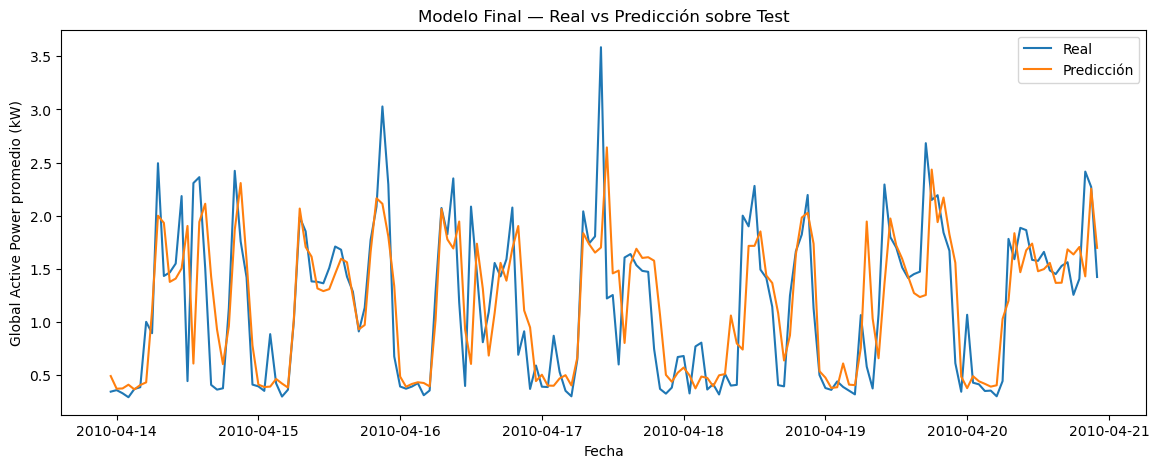

In [119]:
muestra_test = test.iloc[:24 * 7]

pred_test_series = pd.Series(
    pred_test,
    index=test.index
)

fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    muestra_test.index,
    muestra_test[target],
    label="Real"
)

ax.plot(
    muestra_test.index,
    pred_test_series.loc[
        muestra_test.index
    ],
    label="Predicción"
)

ax.set_title(
    "Modelo Final — Real vs Predicción sobre Test"
)

ax.set_xlabel("Fecha")

ax.set_ylabel(
    "Global Active Power promedio (kW)"
)

ax.legend()

plt.show()

La gráfica permite observar visualmente qué tan cerca se encuentran las predicciones del modelo respecto a los valores reales durante el período mostrado.

18.2 Análisis de residuales

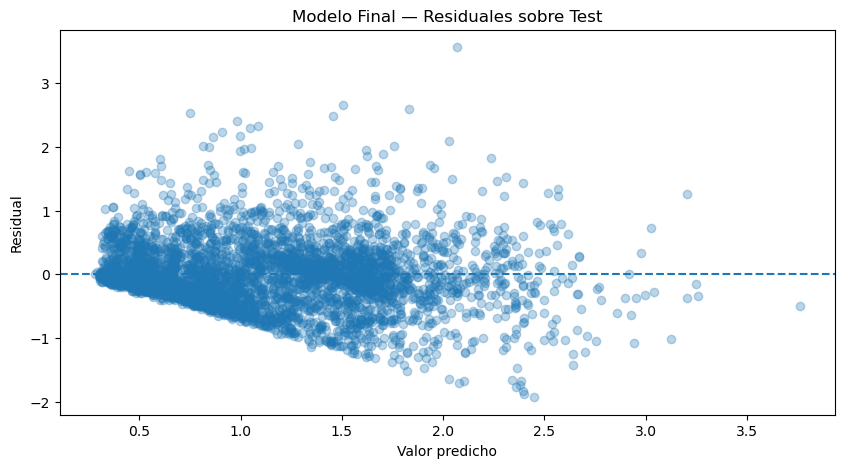

In [120]:
residuos_finales = (
    y_test.to_numpy()
    - pred_test
)

fig_res, ax = plt.subplots(
    figsize=(10, 5)
)

ax.scatter(
    pred_test,
    residuos_finales,
    alpha=0.3
)

ax.axhline(
    0,
    linestyle="--"
)

ax.set_title(
    "Modelo Final — Residuales sobre Test"
)

ax.set_xlabel(
    "Valor predicho"
)

ax.set_ylabel(
    "Residual"
)

plt.show()

Los residuales presentan una dispersión alrededor de cero, pero se observa una tendencia descendente conforme aumentan los valores predichos. Esto indica que los errores no se distribuyen completamente de forma aleatoria y podría existir cierto patrón no capturado por el modelo. Además, se identifican algunos valores atípicos, principalmente residuales positivos de mayor magnitud.

18.3 Feature Importance

In [121]:
importancia_final = pd.DataFrame({

    "Feature":
        features_b,

    "Importance":
        modelo_final.feature_importances_
})

importancia_final = (
    importancia_final
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    importancia_final
)

,Feature,Importance
0,lag_1,0.718578
1,lag_168,0.061556
2,hour_sin,0.045845
3,hour_cos,0.043955
4,lag_24,0.037075
5,rolling_mean_3,0.025671
6,rolling_mean_24,0.019636
7,rolling_std_24,0.016989
8,month_cos,0.011015
9,day_of_week_sin,0.009365


La importancia de características del modelo final muestra que lag_1 es la variable dominante, con un 71.86% de importancia, indicando que el consumo de la hora anterior es el principal predictor del consumo futuro. Le siguen lag_168 con 6.16% y las variables cíclicas de hora hour_sin y hour_cos, con 4.58% y 4.40%, respectivamente. lag_24 también presenta una contribución relevante (3.71%), lo cual evidencia la importancia de los patrones diarios y semanales en el consumo eléctrico. Las variables de ventanas móviles aportan información complementaria, mientras que las variables de calendario presentan menor importancia. En conjunto, los resultados son coherentes con el análisis temporal realizado previamente y muestran que el modelo aprovecha principalmente la dependencia del consumo reciente y sus patrones periódicos.

Visualización

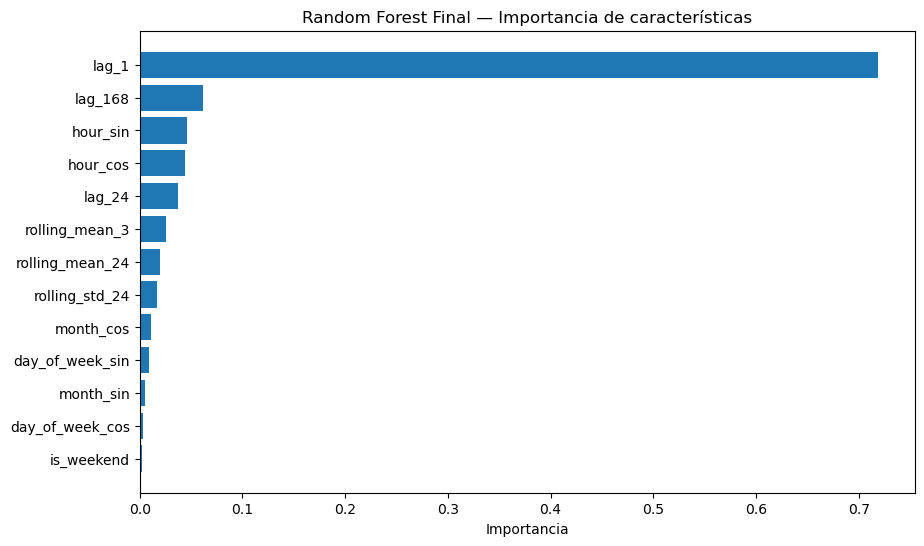

In [122]:
plt.figure(
    figsize=(10, 6)
)

plt.barh(
    importancia_final["Feature"],
    importancia_final["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Random Forest Final — Importancia de características"
)

plt.xlabel(
    "Importancia"
)

plt.show()

El análisis de importancia permite identificar cuáles características tuvieron mayor contribución en las predicciones del Random Forest.


18.4 Verificación de configuración del modelo final

In [123]:
print(
    "Configuración del modelo final"
)

print(
    "n_estimators:",
    modelo_final.n_estimators
)

print(
    "max_depth:",
    modelo_final.max_depth
)

print(
    "min_samples_leaf:",
    modelo_final.min_samples_leaf
)

print(
    "random_state:",
    modelo_final.random_state
)

Configuración del modelo final
n_estimators: 200
max_depth: 10
min_samples_leaf: 2
random_state: 42


La verificación confirma que el modelo final corresponde a la configuración seleccionada previamente mediante TimeSeriesSplit y que los hiperparámetros utilizados durante el reentrenamiento se mantienen consistentes.

n_estimators = 200: el modelo utiliza 200 árboles de decisión. Esta cantidad fue seleccionada porque la configuración obtuvo el mejor desempeño promedio durante la segunda ronda de experimentación.
max_depth = 10: limita la profundidad máxima de los árboles, ayudando a controlar la complejidad del modelo y reduciendo el riesgo de sobreajuste.
min_samples_leaf = 2: cada hoja debe contener al menos 2 observaciones, proporcionando una pequeña regularización adicional.
random_state = 42: garantiza que el entrenamiento sea reproducible, de manera que al ejecutar nuevamente el código bajo las mismas condiciones se obtenga el mismo resultado.

Lo más importante es que esta configuración coincide con la configuración ganadora obtenida mediante TimeSeriesSplit:

200 árboles, max_depth=10 y min_samples_leaf=2.

Además, el modelo fue posteriormente reentrenado utilizando Train + Validation, antes de realizar la evaluación final sobre Test. Por lo tanto, la verificación demuestra que no se cambió accidentalmente la configuración seleccionada durante el proceso.

La configuración del modelo final es correcta, reproducible y consistente con el proceso experimental realizado. Esto respalda que el modelo evaluado sobre Test corresponde realmente al modelo candidato seleccionado y ajustado previamente..

19. Registro final en MLflow

19.1 Registro final completo en MLflow

In [124]:
if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(
    run_name="modelo_final_random_forest_feature_set_b"
):

    # ==========================================
    # PARÁMETROS
    # ==========================================

    mlflow.log_param(
        "algorithm",
        "RandomForestRegressor"
    )

    mlflow.log_param(
        "feature_set",
        "B"
    )

    mlflow.log_param(
        "n_features",
        len(features_b)
    )

    mlflow.log_param(
        "n_estimators",
        modelo_final.n_estimators
    )

    mlflow.log_param(
        "max_depth",
        modelo_final.max_depth
    )

    mlflow.log_param(
        "min_samples_leaf",
        modelo_final.min_samples_leaf
    )

    mlflow.log_param(
        "random_seed",
        modelo_final.random_state
    )

    mlflow.log_param(
        "n_jobs",
        modelo_final.n_jobs
    )

    mlflow.log_param(
        "training_data",
        "Train + Validation"
    )

    mlflow.log_param(
        "training_observations",
        len(y_train_final)
    )

    mlflow.log_param(
        "test_observations",
        len(y_test)
    )

    mlflow.log_param(
        "forecast_horizon",
        "t+1_hour"
    )

    mlflow.log_param(
        "frequency",
        "hourly"
    )

    mlflow.log_param(
        "data_version",
        DATA_VERSION
    )

    # ==========================================
    # MÉTRICAS FINALES
    # ==========================================

    mlflow.log_metric(
        "MAE_test",
        float(metricas_finales["MAE"])
    )

    mlflow.log_metric(
        "RMSE_test",
        float(metricas_finales["RMSE"])
    )

    mlflow.log_metric(
        "MAE_baseline_test",
        float(metricas_baseline_test["MAE"])
    )

    mlflow.log_metric(
        "RMSE_baseline_test",
        float(metricas_baseline_test["RMSE"])
    )

    mlflow.log_metric(
        "MAE_improvement_pct",
        float(mejora_mae_final)
    )

    mlflow.log_metric(
        "RMSE_improvement_pct",
        float(mejora_rmse_final)
    )

    # ==========================================
    # FEATURES
    # ==========================================

    mlflow.log_dict(
        {
            "features": features_b
        },
        "metadata/features.json"
    )

    # ==========================================
    # CONFIGURACIÓN
    # ==========================================

    mlflow.log_dict(
        {
            "algorithm":
                "RandomForestRegressor",

            "feature_set":
                "B",

            "n_features":
                len(features_b),

            "n_estimators":
                modelo_final.n_estimators,

            "max_depth":
                modelo_final.max_depth,

            "min_samples_leaf":
                modelo_final.min_samples_leaf,

            "random_seed":
                modelo_final.random_state,

            "forecast_horizon":
                "t+1_hour",

            "frequency":
                "hourly",

            "data_version":
                DATA_VERSION
        },
        "metadata/model_configuration.json"
    )

    # ==========================================
    # REAL VS PREDICCIÓN
    # ==========================================

    muestra_test = test.iloc[:24 * 7]

    pred_test_series = pd.Series(
        pred_test,
        index=test.index
    )

    fig, ax = plt.subplots(
        figsize=(14, 5)
    )

    ax.plot(
        muestra_test.index,
        muestra_test[target],
        label="Real"
    )

    ax.plot(
        muestra_test.index,
        pred_test_series.loc[
            muestra_test.index
        ],
        label="Predicción"
    )

    ax.set_title(
        "Modelo Final — Real vs Predicción sobre Test"
    )

    ax.set_xlabel("Fecha")

    ax.set_ylabel(
        "Global Active Power promedio (kW)"
    )

    ax.legend()

    mlflow.log_figure(
        fig,
        "plots/forecast_test.png"
    )

    plt.close(fig)

    # ==========================================
    # RESIDUALES
    # ==========================================

    residuos_finales = (
        y_test.to_numpy()
        - pred_test
    )

    fig_res, ax = plt.subplots(
        figsize=(10, 5)
    )

    ax.scatter(
        pred_test,
        residuos_finales,
        alpha=0.3
    )

    ax.axhline(
        0,
        linestyle="--"
    )

    ax.set_title(
        "Modelo Final — Residuales sobre Test"
    )

    ax.set_xlabel(
        "Valor predicho"
    )

    ax.set_ylabel(
        "Residual"
    )

    mlflow.log_figure(
        fig_res,
        "plots/residuals_test.png"
    )

    plt.close(fig_res)

    # ==========================================
    # FEATURE IMPORTANCE
    # ==========================================

    importancia = pd.DataFrame({

        "Feature":
            features_b,

        "Importance":
            modelo_final.feature_importances_
    })

    importancia = (
        importancia
        .sort_values(
            "Importance",
            ascending=False
        )
    )

    fig_imp, ax = plt.subplots(
        figsize=(10, 6)
    )

    ax.barh(
        importancia["Feature"],
        importancia["Importance"]
    )

    ax.invert_yaxis()

    ax.set_title(
        "Modelo Final — Feature Importance"
    )

    ax.set_xlabel(
        "Importancia"
    )

    ax.set_ylabel(
        "Feature"
    )

    mlflow.log_figure(
        fig_imp,
        "plots/feature_importance.png"
    )

    plt.close(fig_imp)

    # ==========================================
    # MODELO
    # ==========================================

    ejemplo_final = X_train_final.head(20)

    signature_final = infer_signature(
        ejemplo_final,
        modelo_final.predict(ejemplo_final)
    )

    mlflow.sklearn.log_model(
        sk_model=modelo_final,
        name="model",
        signature=signature_final,
        input_example=X_train_final.head(5),
        registered_model_name="random_forest_feature_set_b"
    )

print(
    "Modelo final registrado correctamente en MLflow."
)

c:\Users\hijad\anaconda3\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Successfully registered model 'random_forest_feature_set_b'.
2026/08/28 10:40:03 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: random_forest_feature_set_b, version 1


🏃 View run modelo_final_random_forest_feature_set_b at: http://127.0.0.1:5000/#/experiments/1/runs/9da5713001ee4d4d817a84823513485c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Modelo final registrado correctamente en MLflow.


Created version '1' of model 'random_forest_feature_set_b'.
